# BACE Publication-Ready Analysis (ACS/IEEE Style)

Dieses Notebook fokussiert explizit die Thesis-Storyline:

1. **Loss Stabilisation** durch Stage-1-Pretraining (PT-S1) der ChebNet-Komponente in **SEG** und **TAME-Fusion**
2. **Johnson-Lindenstrauss (JL) als Epiphänomen**: Distanztreue ist messbar, erklärt aber nicht kausal die Performance
3. **Gating Modality Preference** in **TAME** (Graph/Text/Descriptor)
4. **Ähnlichkeitskorrelationen** (Tanimoto, |Δy| vs. Latent-Distanzen)

Zusätzlich wird ein evolutionärer roter Faden umgesetzt:
- Klassisch: RF + Deskriptoren
- Bi-modal: SEG / TAME-Fusion
- Tri-modal: TAME (MoE-Routing)

In [2]:
import sys
from pathlib import Path
from contextlib import contextmanager
import warnings

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from matplotlib import rcParams

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace: {workspace_root}')
print(f'Device: {device}')

warnings.filterwarnings('ignore', message='.*findfont.*')

# Clean publication-like defaults without platform-specific font warnings
rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 500,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#1f2937',
    'axes.linewidth': 0.9,
    'font.family': 'DejaVu Serif',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'grid.alpha': 0.22,
    'grid.color': '#9ca3af',
    'grid.linestyle': '--',
})

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [3]:
def classification_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.clip(np.asarray(y_prob).reshape(-1), 0.0, 1.0)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    rows = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            rows.append([0.0] * len(desc_names))
            continue
        all_d = Descriptors.CalcMolDescriptors(m)
        cur = []
        for n in desc_names:
            v = all_d.get(n, 0.0)
            try:
                fv = float(v)
            except Exception:
                fv = 0.0
            if not np.isfinite(fv):
                fv = 0.0
            cur.append(fv)
        rows.append(cur)
    return np.asarray(rows, dtype=np.float32), desc_names

def compute_tanimoto_pairs(smiles_list, radius=2, nbits=2048):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits) for m in mols if m is not None]
    vals = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            vals.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return np.asarray(vals, dtype=np.float32)

tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

TRAIN_SMILES = list(train_dc.ids)
VALID_SMILES = list(valid_dc.ids)
TEST_SMILES = list(test_dc.ids)

TRAIN_Y = train_dc.y.reshape(-1).astype(np.float32)
VALID_Y = valid_dc.y.reshape(-1).astype(np.float32)
TEST_Y = test_dc.y.reshape(-1).astype(np.float32)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'binding_fast_text_embeddings_compact.npz'
cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles)).float()
n_train = len(TRAIN_SMILES)
n_valid = len(VALID_SMILES)
TRAIN_TEXT = all_emb[:n_train]
VALID_TEXT = all_emb[n_train:n_train + n_valid]
TEST_TEXT = all_emb[n_train + n_valid:]

TRAIN_DESC, DESC_NAMES = rdkit_descriptor_matrix(TRAIN_SMILES)
VALID_DESC, _ = rdkit_descriptor_matrix(VALID_SMILES)
TEST_DESC, _ = rdkit_descriptor_matrix(TEST_SMILES)

TANIMOTO_TEST = compute_tanimoto_pairs(TEST_SMILES)
DELTA_Y_TEST = pdist(TEST_Y.reshape(-1, 1), metric='euclidean')

print(f'Train/Val/Test: {len(TRAIN_SMILES)}/{len(VALID_SMILES)}/{len(TEST_SMILES)}')
print(f'Text dim: {TRAIN_TEXT.shape[1]} | Desc dim: {TRAIN_DESC.shape[1]}')
print(f'Positive rates: train={TRAIN_Y.mean():.3f}, val={VALID_Y.mean():.3f}, test={TEST_Y.mean():.3f}')

Loading embeddings from binding_fast_text_embeddings_compact.npz...
  Loaded 1513 entries, dim=3072
  Memory mode: mapped
Train/Val/Test: 1210/151/152
Text dim: 3072 | Desc dim: 217
Positive rates: train=0.426, val=0.556, test=0.605


[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerator
[17:59:06] DEPRECATION WARNING: please use MorganGenerat

In [4]:
SEEDS = [11, 22, 33, 44, 55]
MAX_EPOCHS = 140
BATCH_SIZE = 64

SEG_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'set2set',
    'set2set_processing_steps': 6, 'fusion': 'cross_mha', 'fusion_dim': 64, 'fusion_n_heads': 8,
    'dropout': 0.3, 'fusion_dropout': 0.3, 'head_dropout': 0.3, 'head_hidden_dim': 64,
    'text_projection_dim': 64, 'learning_rate': 8e-4, 'weight_decay': 8e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20
}

TAME_FUSION_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'set2set',
    'set2set_processing_steps': 6, 'fusion': 'cross_mha', 'fusion_dim': 64, 'fusion_n_heads': 8,
    'moe_hidden_dim': 64, 'projection_dropout': 0.25, 'router_dropout': 0.25,
    'head_hidden_dim': 64, 'head_dropout': 0.3, 'learning_rate': 8e-4, 'weight_decay': 8e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20,
    'desc_modality_dropout': 0.20, 'gate_balance_weight': 0.003
}

TAME_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'set2set',
    'set2set_processing_steps': 6, 'fusion_hidden_dim': 64,
    'projection_dropout': 0.25, 'router_dropout': 0.25,
    'head_hidden_dim': 64, 'head_dropout': 0.3,
    'learning_rate': 8e-4, 'weight_decay': 8e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20,
    'desc_modality_dropout': 0.20, 'gate_balance_weight': 0.003
}

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    stage_cfg = {'stage1_node': {'pattern_prefix': 'cheb_foundation_stage1'}}
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = f"{prefix}__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt"
    cands = sorted([p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name], key=lambda p: p.stat().st_mtime, reverse=True)
    if not cands:
        raise FileNotFoundError(f'No checkpoint matching {pattern}')
    return cands[0]

def _arch_from_encoder_state(enc_state):
    layer_ids = sorted({int(k.split('.')[1]) for k in enc_state if k.startswith('layers.') and k.endswith('.weight')})
    fw = enc_state[f'layers.{layer_ids[0]}.weight']
    return {'K': int(fw.shape[0]), 'hidden_channels': int(fw.shape[-1]), 'num_layers': int(max(layer_ids) + 1)}

def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if payload.get('pretraining_stage') != expected_stage:
        raise RuntimeError('Checkpoint stage mismatch')
    msd = payload.get('model_state_dict', {})
    enc = {k.replace('encoder.', '', 1): v for k, v in msd.items() if k.startswith('encoder.')}
    arch = _arch_from_encoder_state(enc)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(f'Encoder arch mismatch in {ckpt_path.name}: {k}')
    return enc

SEG_ARCH = {'hidden_channels': SEG_FIT['hidden_channels'], 'num_layers': SEG_FIT['num_layers'], 'K': SEG_FIT['K'], 'pool': SEG_FIT['pool']}
TF_ARCH = {'hidden_channels': TAME_FUSION_FIT['hidden_channels'], 'num_layers': TAME_FUSION_FIT['num_layers'], 'K': TAME_FUSION_FIT['K'], 'pool': TAME_FUSION_FIT['pool']}
TAME_ARCH = {'hidden_channels': TAME_FIT['hidden_channels'], 'num_layers': TAME_FIT['num_layers'], 'K': TAME_FIT['K'], 'pool': TAME_FIT['pool']}

seg_ckpt = resolve_pretrain_checkpoint('stage1_node', **SEG_ARCH)
tf_ckpt = resolve_pretrain_checkpoint('stage1_node', **TF_ARCH)
tame_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_ARCH)

SEG_STAGE1 = load_pretrained_encoder_state(seg_ckpt, 'stage1_node', SEG_ARCH)
TF_STAGE1 = load_pretrained_encoder_state(tf_ckpt, 'stage1_node', TF_ARCH)
TAME_STAGE1 = load_pretrained_encoder_state(tame_ckpt, 'stage1_node', TAME_ARCH)

print('Loaded PT-S1 checkpoints:')
print('  SEG:', seg_ckpt.name)
print('  TAME-Fusion:', tf_ckpt.name)
print('  TAME:', tame_ckpt.name)

Loaded PT-S1 checkpoints:
  SEG: cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
  TAME-Fusion: cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
  TAME: cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [5]:
def make_seg_config():
    return SEGPredictorConfig(
        task='classification', num_tasks=1,
        hidden_channels=SEG_FIT['hidden_channels'], K=SEG_FIT['K'], num_layers=SEG_FIT['num_layers'],
        dropout=SEG_FIT['dropout'], pool=SEG_FIT['pool'],
        set2set_processing_steps=SEG_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]), text_projection_dim=SEG_FIT['text_projection_dim'],
        fusion=SEG_FIT['fusion'], fusion_dim=SEG_FIT['fusion_dim'], fusion_n_heads=SEG_FIT['fusion_n_heads'], fusion_dropout=SEG_FIT['fusion_dropout'],
        head_type='mlp', head_hidden_dim=SEG_FIT['head_hidden_dim'], head_dropout=SEG_FIT['head_dropout'],
    )

def make_tame_fusion_config():
    return TAMEFusionPredictorConfig(
        task='classification', num_tasks=1,
        hidden_channels=TAME_FUSION_FIT['hidden_channels'], K=TAME_FUSION_FIT['K'], num_layers=TAME_FUSION_FIT['num_layers'],
        pool=TAME_FUSION_FIT['pool'], set2set_processing_steps=TAME_FUSION_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]),
        fusion=TAME_FUSION_FIT['fusion'], fusion_dim=TAME_FUSION_FIT['fusion_dim'], fusion_n_heads=TAME_FUSION_FIT['fusion_n_heads'], fusion_dropout=TAME_FUSION_FIT['router_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT['moe_hidden_dim'], projection_dropout=TAME_FUSION_FIT['projection_dropout'],
        router_dropout=TAME_FUSION_FIT['router_dropout'], head_hidden_dim=TAME_FUSION_FIT['head_hidden_dim'], head_dropout=TAME_FUSION_FIT['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT['gate_balance_weight'], desc_modality_dropout=TAME_FUSION_FIT['desc_modality_dropout'],
    )

def make_tame_config():
    return TAMEPredictorConfig(
        task='classification', num_tasks=1,
        hidden_channels=TAME_FIT['hidden_channels'], K=TAME_FIT['K'], num_layers=TAME_FIT['num_layers'],
        pool=TAME_FIT['pool'], set2set_processing_steps=TAME_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]), fusion_hidden_dim=TAME_FIT['fusion_hidden_dim'],
        projection_dropout=TAME_FIT['projection_dropout'], router_dropout=TAME_FIT['router_dropout'],
        head_hidden_dim=TAME_FIT['head_hidden_dim'], head_dropout=TAME_FIT['head_dropout'],
        gate_balance_weight=TAME_FIT['gate_balance_weight'], desc_modality_dropout=TAME_FIT['desc_modality_dropout'],
    )

def eval_seg_auc_epoch(seg, graphs, text_emb, labels, idx, batch_size=64):
    seg._set_eval_mode()
    y_true, y_prob = [], []
    with torch.no_grad():
        for s in range(0, len(idx), batch_size):
            bidx = idx[s:s + batch_size]
            pack = seg._make_batch(graphs, text_emb, labels, bidx)
            if pack is None:
                continue
            x, ei, ew, b, bt, by = pack
            x, ei, ew, b = seg._numpy_to_tensors(x, ei, ew, b)
            bt = torch.from_numpy(bt.astype(np.float32)).to(seg.device)
            prob = seg._forward(x, ei, ew, b, bt).squeeze(-1)
            p = prob.cpu().numpy().reshape(-1)
            y_true.extend(np.asarray(by).reshape(-1).tolist())
            y_prob.extend(p.tolist())
    return float(roc_auc_score(np.asarray(y_true), np.asarray(y_prob)))

def train_seg_with_auc_curve(seed, init_state=None):
    torch.manual_seed(int(seed)); np.random.seed(int(seed))
    seg = SEGPredictor(config=make_seg_config(), device=str(device))
    graphs, in_ch = seg._precompute_graphs(TRAIN_SMILES, verbose=False)
    seg._in_channels = in_ch
    seg._build_model()
    if init_state is not None:
        seg._encoder.load_state_dict(init_state, strict=True)

    y = TRAIN_Y.astype(np.float32).reshape(-1, 1)
    yv = VALID_Y.astype(np.float32).reshape(-1, 1)
    train_idx = np.arange(len(TRAIN_SMILES))
    val_idx = list(range(len(VALID_SMILES)))
    v_graphs, _ = seg._precompute_graphs(VALID_SMILES, verbose=False)

    opt = torch.optim.AdamW(seg._get_parameters(), lr=SEG_FIT['learning_rate'], weight_decay=SEG_FIT['weight_decay'])
    # SEGPredictor classification head already applies sigmoid -> use BCELoss (not BCEWithLogitsLoss)
    loss_fn = torch.nn.BCELoss()
    rng = np.random.default_rng(int(seed))
    hist = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_state, best_val, stale = None, float('inf'), 0

    for epoch in range(SEG_FIT['num_epochs']):
        tr = seg._train_epoch(graphs, TRAIN_TEXT.numpy(), y, train_idx.copy(), SEG_FIT['batch_size'], opt, loss_fn, rng)
        vl = seg._evaluate(v_graphs, VALID_TEXT.numpy(), yv, val_idx, SEG_FIT['batch_size'], loss_fn)
        vauc = eval_seg_auc_epoch(seg, v_graphs, VALID_TEXT.numpy(), yv, val_idx, SEG_FIT['batch_size'])
        hist['train_loss'].append(float(tr)); hist['val_loss'].append(float(vl)); hist['val_auc'].append(float(vauc))
        if vl < best_val:
            best_val = float(vl); best_state = seg._get_state_dict(); stale = 0
        else:
            stale += 1
            if stale >= SEG_FIT['patience']:
                break

    if best_state is not None:
        seg._load_state_dict(best_state)
    seg._is_fitted = True
    test_prob = np.asarray(seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy()), dtype=np.float32).reshape(-1)
    metrics = classification_metrics(TEST_Y, test_prob)
    return seg, hist, metrics

def train_tame_fusion(seed, init_state=None):
    cfg = make_tame_fusion_config()
    m = TAMEFusionPredictor(config=cfg, device=str(device))
    h = m.fit(
        TRAIN_SMILES, TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT.numpy(), val_text_embeddings=VALID_TEXT.numpy(),
        descriptor_features=TRAIN_DESC, val_descriptor_features=VALID_DESC,
        num_epochs=TAME_FUSION_FIT['num_epochs'], batch_size=TAME_FUSION_FIT['batch_size'],
        learning_rate=TAME_FUSION_FIT['learning_rate'], weight_decay=TAME_FUSION_FIT['weight_decay'],
        patience=TAME_FUSION_FIT['patience'], seed=int(seed), verbose=False,
        init_encoder_state=init_state,
    )
    test_prob = np.asarray(m.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy(), descriptor_features=TEST_DESC), dtype=np.float32).reshape(-1)
    metrics = classification_metrics(TEST_Y, test_prob)
    return m, h, metrics

def train_tame(seed, init_state=None):
    cfg = make_tame_config()
    m = TAMEPredictor(config=cfg, device=str(device))
    h = m.fit(
        TRAIN_SMILES, TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT.numpy(), val_text_embeddings=VALID_TEXT.numpy(),
        descriptor_features=TRAIN_DESC, val_descriptor_features=VALID_DESC,
        num_epochs=TAME_FIT['num_epochs'], batch_size=TAME_FIT['batch_size'],
        learning_rate=TAME_FIT['learning_rate'], weight_decay=TAME_FIT['weight_decay'],
        patience=TAME_FIT['patience'], seed=int(seed), verbose=False,
        init_encoder_state=init_state,
    )
    test_prob = np.asarray(m.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy(), descriptor_features=TEST_DESC), dtype=np.float32).reshape(-1)
    metrics = classification_metrics(TEST_Y, test_prob)
    return m, h, metrics

In [6]:
RUN_TRAINING = True  # Set to False to skip training and load existing results
art_dir = workspace_root / 'benchmarking' / 'results'
art_dir.mkdir(parents=True, exist_ok=True)
art_pt = art_dir / 'bace_pubready_v1_runs.pt'
art_csv = art_dir / 'bace_pubready_v1_metrics.csv'

if RUN_TRAINING:
    RUNS = {
        'SEG_VANILLA': {},
        'SEG_PT_S1': {},
        'TAME_FUSION_VANILLA': {},
        'TAME_FUSION_PT_S1': {},
        'TAME_VANILLA': {},
        'TAME_PT_S1': {},
    }
    rows = []

    for seed in SEEDS:
        print(f'Running seed {seed}...')

        seg_v, seg_v_h, seg_v_m = train_seg_with_auc_curve(seed, init_state=None)
        RUNS['SEG_VANILLA'][seed] = {'history': seg_v_h, 'metrics': seg_v_m, 'model': seg_v}
        rows.append({'model': 'SEG_VANILLA', 'seed': seed, **seg_v_m})

        seg_p, seg_p_h, seg_p_m = train_seg_with_auc_curve(seed, init_state=SEG_STAGE1)
        RUNS['SEG_PT_S1'][seed] = {'history': seg_p_h, 'metrics': seg_p_m, 'model': seg_p}
        rows.append({'model': 'SEG_PT_S1', 'seed': seed, **seg_p_m})

        tf_v, tf_v_h, tf_v_m = train_tame_fusion(seed, init_state=None)
        RUNS['TAME_FUSION_VANILLA'][seed] = {'history': tf_v_h, 'metrics': tf_v_m, 'model': tf_v}
        rows.append({'model': 'TAME_FUSION_VANILLA', 'seed': seed, **tf_v_m})

        tf_p, tf_p_h, tf_p_m = train_tame_fusion(seed, init_state=TF_STAGE1)
        RUNS['TAME_FUSION_PT_S1'][seed] = {'history': tf_p_h, 'metrics': tf_p_m, 'model': tf_p}
        rows.append({'model': 'TAME_FUSION_PT_S1', 'seed': seed, **tf_p_m})

        mm_v, mm_v_h, mm_v_m = train_tame(seed, init_state=None)
        RUNS['TAME_VANILLA'][seed] = {'history': mm_v_h, 'metrics': mm_v_m, 'model': mm_v}
        rows.append({'model': 'TAME_VANILLA', 'seed': seed, **mm_v_m})

        mm_p, mm_p_h, mm_p_m = train_tame(seed, init_state=TAME_STAGE1)
        RUNS['TAME_PT_S1'][seed] = {'history': mm_p_h, 'metrics': mm_p_m, 'model': mm_p}
        rows.append({'model': 'TAME_PT_S1', 'seed': seed, **mm_p_m})

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(art_csv, index=False)
    torch.save(RUNS, art_pt)
else:
    RUNS = torch.load(art_pt, map_location='cpu', weights_only=False)
    metrics_df = pd.read_csv(art_csv)
    metrics_df['model'] = metrics_df['model'].replace({'TAME_VANILLA': 'TAME_VANILLA', 'TAME_PT_S1': 'TAME_PT_S1'})

    # Ensure loaded modules and model handles are on the active runtime device.
    for mk in RUNS:
        for seed in RUNS[mk]:
            mdl = RUNS[mk][seed].get('model', None)
            if mdl is None:
                continue
            if hasattr(mdl, 'device'):
                mdl.device = device
            for part in ['_encoder', '_pooling', '_fusion', '_head', '_text_proj', '_moe_module']:
                comp = getattr(mdl, part, None)
                if comp is not None and hasattr(comp, 'to'):
                    comp.to(device)

display(metrics_df.groupby('model')[['roc_auc','accuracy','f1']].agg(['mean','std']).round(4))

Running seed 11...
Running seed 22...
Running seed 33...
Running seed 44...
Running seed 55...


roc_auc         accuracy              f1        
                       mean     std     mean     std    mean     std
model                                                               
SEG_PT_S1            0.8082  0.0460   0.6842  0.0505  0.6844  0.0743
SEG_VANILLA          0.8111  0.0081   0.7408  0.0253  0.7740  0.0298
TAME_FUSION_PT_S1    0.8175  0.0164   0.7395  0.0201  0.7617  0.0225
TAME_FUSION_VANILLA  0.7905  0.0080   0.7197  0.0151  0.7398  0.0160
TAME_PT_S1           0.8373  0.0174   0.7434  0.0197  0.7631  0.0252
TAME_VANILLA         0.7993  0.0154   0.7263  0.0151  0.7478  0.0198

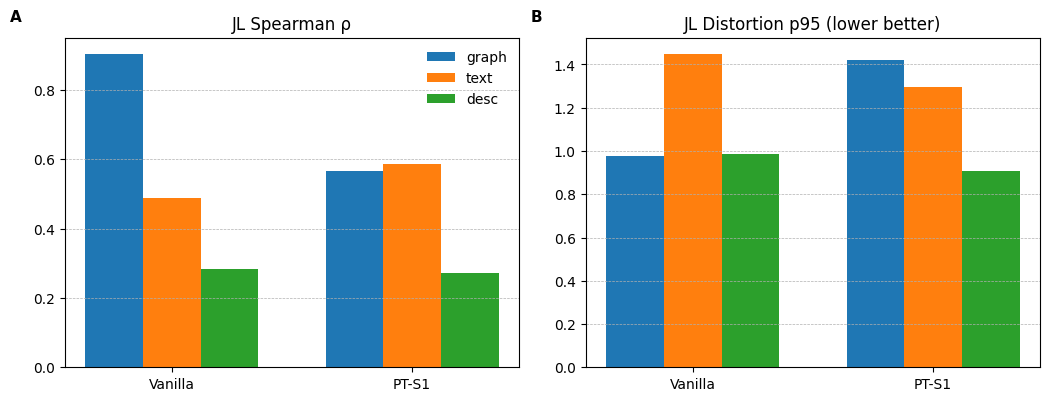

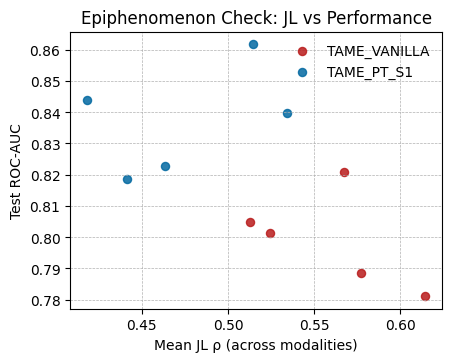

Spearman corr(JL rho, AUC): SignificanceResult(statistic=np.float64(-0.5636363636363636), pvalue=np.float64(0.0897240283170912))
Spearman corr(JL distortion, AUC): SignificanceResult(statistic=np.float64(0.2727272727272727), pvalue=np.float64(0.4458383415427516))


In [7]:
# === Figure 2: JL all-modalities + Epiphenomenon test ===
plt.style.use('default')
def jl_stats(high_X, low_X):
    d_hi = pdist(np.asarray(high_X, dtype=np.float32), metric='euclidean')
    d_lo = pdist(np.asarray(low_X, dtype=np.float32), metric='euclidean')
    rho, _ = spearmanr(d_hi, d_lo)
    ratio = d_lo / (d_hi + 1e-10)
    med = np.median(ratio)
    p95 = np.percentile(np.abs((ratio / med) - 1.0), 95)
    return float(rho), float(p95)

def extract_tame_modalities(model, smiles, text_emb, desc):
    model._set_eval_mode()
    g_hi, t_hi, d_hi, g_lo, t_lo, d_lo, fused = [], [], [], [], [], [], []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s+64]
            tt = text_emb[s:s+64]
            dd = desc[s:s+64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_np = model._transform_descriptors(np.asarray(dd, dtype=np.float32))
            dd_t = torch.from_numpy(dd_np).to(model.device)
            _, aux = model._forward(x, ei, ew, b, tt_t, dd_t)
            node = model._encoder(x, ei, ew, b)
            graph = model._pooling(node, b)
            g_proj = model._moe_module.graph_proj(graph)
            t_proj = model._moe_module.text_proj(tt_t)
            d_proj = model._moe_module.desc_proj(dd_t)
            g_hi.append(graph.cpu().numpy()); t_hi.append(tt_t.cpu().numpy()); d_hi.append(dd_t.cpu().numpy())
            g_lo.append(g_proj.cpu().numpy()); t_lo.append(t_proj.cpu().numpy()); d_lo.append(d_proj.cpu().numpy())
            fused.append(aux['fused_emb'].cpu().numpy())
    cat = lambda xs: np.concatenate(xs, axis=0)
    return {
        'graph_hi': cat(g_hi), 'text_hi': cat(t_hi), 'desc_hi': cat(d_hi),
        'graph_lo': cat(g_lo), 'text_lo': cat(t_lo), 'desc_lo': cat(d_lo), 'fused': cat(fused),
    }

jl_rows = []
for mk in ['TAME_VANILLA', 'TAME_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        em = extract_tame_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        # Sanity check: modal extraction must preserve sample count and finite values.
        assert em['fused'].shape[0] == len(TEST_SMILES), f'Unexpected extracted size for {mk} seed={seed}'
        assert np.isfinite(em['fused']).all(), f'Non-finite fused embeddings for {mk} seed={seed}'
        for mod in ['graph', 'text', 'desc']:
            rho, p95 = jl_stats(em[f'{mod}_hi'], em[f'{mod}_lo'])
            jl_rows.append({
                'model': mk, 'seed': seed, 'modality': mod, 'rho': rho, 'p95_distortion': p95,
                'roc_auc': RUNS[mk][seed]['metrics']['roc_auc'],
            })
jl_df = pd.DataFrame(jl_rows)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9), constrained_layout=True)
fig.patch.set_facecolor('white')
for _ax in axes:
    _ax.set_facecolor('white')

for i, metric in enumerate(['rho', 'p95_distortion']):
    ax = axes[i]
    piv = jl_df.groupby(['model','modality'])[metric].mean().unstack('modality').loc[['TAME_VANILLA','TAME_PT_S1']]
    x = np.arange(len(piv.index))
    w = 0.24
    for j, mod in enumerate(['graph','text','desc']):
        ax.bar(x + (j-1)*w, piv[mod].values, width=w, label=mod)
    ax.set_xticks(x, ['Vanilla','PT-S1'])
    ax.set_title('JL Spearman ρ' if metric == 'rho' else 'JL Distortion p95 (lower better)')
    ax.grid(True, axis='y', ls='--', lw=0.5)
    if i == 0:
        ax.legend(frameon=False)

for ax, label in zip(axes, ['A', 'B']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=11, fontweight='bold')

plt.show()

# Epiphenomenon: does JL explain AUC across seeds?
epi = jl_df.groupby(['model','seed'])[['rho','p95_distortion','roc_auc']].mean().reset_index()
fig, ax = plt.subplots(figsize=(4.8, 3.6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for mk, c, lbl in [('TAME_VANILLA','#b91c1c','TAME_VANILLA'),('TAME_PT_S1','#0369a1','TAME_PT_S1')]:
    sub = epi[epi['model'] == mk]
    ax.scatter(sub['rho'], sub['roc_auc'], s=34, alpha=0.85, label=lbl, color=c)
ax.set_xlabel('Mean JL ρ (across modalities)')
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Epiphenomenon Check: JL vs Performance')
ax.grid(True, ls='--', lw=0.5)
ax.legend(frameon=False)
plt.show()

print('Spearman corr(JL rho, AUC):', spearmanr(epi['rho'], epi['roc_auc']))
print('Spearman corr(JL distortion, AUC):', spearmanr(epi['p95_distortion'], epi['roc_auc']))

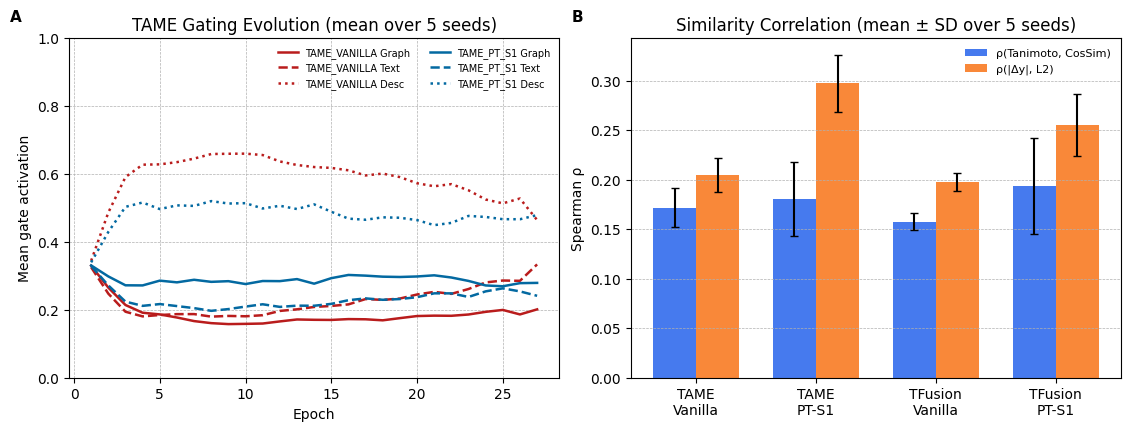

rho_tanimoto_cos         rho_deltaY_l2        
                                mean     std          mean     std
model                                                             
TAME_FUSION_PT_S1             0.1932  0.0484        0.2552  0.0316
TAME_FUSION_VANILLA           0.1577  0.0090        0.1976  0.0089
TAME_PT_S1                    0.1805  0.0378        0.2974  0.0290
TAME_VANILLA                  0.1715  0.0197        0.2048  0.0167

In [8]:
# === Figure 3: Gating dynamics (TAME) + Similarity correlations ===
plt.style.use('default')
def mean_padded_curves(curves):
    max_len = max(len(c) for c in curves)
    arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
    for i, c in enumerate(curves):
        c = np.asarray(c, dtype=np.float32)
        arr[i, :len(c)] = c
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)
fig.patch.set_facecolor('white')
for _ax in axes:
    _ax.set_facecolor('white')

# Left panel: gates
for mk, color, label_prefix in [('TAME_VANILLA', '#b91c1c', 'TAME_VANILLA'), ('TAME_PT_S1', '#0369a1', 'TAME_PT_S1')]:
    g_curves = [RUNS[mk][s]['history']['graph_gate'] for s in sorted(RUNS[mk].keys())]
    t_curves = [RUNS[mk][s]['history']['text_gate'] for s in sorted(RUNS[mk].keys())]
    d_curves = [RUNS[mk][s]['history']['desc_gate'] for s in sorted(RUNS[mk].keys())]
    gm, gs = mean_padded_curves(g_curves)
    tm, ts = mean_padded_curves(t_curves)
    dm, ds = mean_padded_curves(d_curves)
    x = np.arange(1, len(gm)+1)
    ax = axes[0]
    ax.plot(x, gm, lw=1.8, color=color, ls='-', label=f'{label_prefix} Graph')
    ax.plot(x, tm, lw=1.8, color=color, ls='--', label=f'{label_prefix} Text')
    ax.plot(x, dm, lw=1.8, color=color, ls=':', label=f'{label_prefix} Desc')

axes[0].set_title('TAME Gating Evolution (mean over 5 seeds)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean gate activation')
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(True, ls='--', lw=0.5)
axes[0].legend(frameon=False, ncol=2, fontsize=7)

# Right panel: similarity correlations with robust latent extraction

def fused_embedding_tame(model, smiles, text_emb, desc):
    model._set_eval_mode()
    outs = []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s+64]
            tt = text_emb[s:s+64]
            dd = desc[s:s+64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(np.asarray(dd, dtype=np.float32))).to(model.device)
            _, aux = model._forward(x, ei, ew, b, tt_t, dd_t)
            outs.append(aux['fused_emb'].cpu().numpy())
    emb = np.concatenate(outs, axis=0)
    return emb


def fused_embedding_tame_fusion(model, smiles, text_emb, desc):
    model._set_eval_mode()
    outs = []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s+64]
            tt = text_emb[s:s+64]
            dd = desc[s:s+64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(np.asarray(dd, dtype=np.float32))).to(model.device)
            _, aux = model._forward(x, ei, ew, b, tt_t, dd_t)
            outs.append(aux['fused_emb'].cpu().numpy())
    emb = np.concatenate(outs, axis=0)
    return emb

corr_rows = []
for mk in ['TAME_VANILLA', 'TAME_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        if mk.startswith('TAME'):
            emb = fused_embedding_tame(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        else:
            emb = fused_embedding_tame_fusion(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)

        assert emb.shape[0] == len(TEST_SMILES), f'Unexpected extracted size for {mk} seed={seed}'
        assert np.isfinite(emb).all(), f'Non-finite fused embeddings for {mk} seed={seed}'

        cos_sim = 1.0 - pdist(emb, metric='cosine')
        l2_dist = pdist(emb, metric='euclidean')

        rho_t, _ = spearmanr(TANIMOTO_TEST, cos_sim, nan_policy='omit')
        rho_y, _ = spearmanr(DELTA_Y_TEST, l2_dist, nan_policy='omit')

        display_model = 'TAME_VANILLA' if mk == 'TAME_VANILLA' else ('TAME_PT_S1' if mk == 'TAME_PT_S1' else mk)
        corr_rows.append({
            'model': display_model,
            'seed': seed,
            'rho_tanimoto_cos': float(rho_t) if np.isfinite(rho_t) else np.nan,
            'rho_deltaY_l2': float(rho_y) if np.isfinite(rho_y) else np.nan,
        })

corr_df = pd.DataFrame(corr_rows)

order = ['TAME_VANILLA', 'TAME_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']
labels = ['TAME\nVanilla', 'TAME\nPT-S1', 'TFusion\nVanilla', 'TFusion\nPT-S1']
p_mean = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].mean().reindex(order)
p_std = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].std().reindex(order)

x = np.arange(len(order))
w = 0.36
axes[1].bar(x - w/2, p_mean['rho_tanimoto_cos'].values, yerr=p_std['rho_tanimoto_cos'].fillna(0).values, capsize=3, width=w, color='#2563eb', alpha=0.85, label='ρ(Tanimoto, CosSim)')
axes[1].bar(x + w/2, p_mean['rho_deltaY_l2'].values, yerr=p_std['rho_deltaY_l2'].fillna(0).values, capsize=3, width=w, color='#f97316', alpha=0.85, label='ρ(|Δy|, L2)')
axes[1].set_xticks(x, labels)
axes[1].set_title('Similarity Correlation (mean ± SD over 5 seeds)')
axes[1].set_ylabel('Spearman ρ')
axes[1].grid(True, axis='y', ls='--', lw=0.5)
axes[1].legend(frameon=False, fontsize=8)

for ax, label in zip(axes, ['A', 'B']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=11, fontweight='bold')

plt.show()
display(corr_df.groupby('model')[['rho_tanimoto_cos','rho_deltaY_l2']].agg(['mean','std']).round(4))

In [9]:
# === Export report assets ===
report_img_dir = Path(r'C:\Users\robsc\Nextcloud\Studium\Master Chemie\PC Modul\PC F-Praktikum BASF\PC F-Bericht\images')
report_img_dir.mkdir(parents=True, exist_ok=True)

summary_path = art_dir / 'bace_pubready_v1_summary.csv'
corr_path = art_dir / 'bace_pubready_v1_similarity_corr.csv'
jl_path = art_dir / 'bace_pubready_v1_jl.csv'

metrics_df.to_csv(summary_path, index=False)
corr_df.to_csv(corr_path, index=False)
jl_df.to_csv(jl_path, index=False)

print('Saved:')
print(' ', summary_path.resolve())
print(' ', corr_path.resolve())
print(' ', jl_path.resolve())
print('Notebook artifacts:', art_pt.resolve(), art_csv.resolve())

Saved:
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_pubready_v1_summary.csv
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_pubready_v1_similarity_corr.csv
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_pubready_v1_jl.csv
Notebook artifacts: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_pubready_v1_runs.pt C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_pubready_v1_metrics.csv


In [10]:
# Audit checks: extraction integrity + loss outlier diagnostics

audit_rows = []
for mk in ['SEG_VANILLA', 'SEG_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1', 'TAME_VANILLA', 'TAME_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        hist = RUNS[mk][seed]['history']
        val_loss = np.asarray(hist.get('val_loss', []), dtype=np.float32)
        if val_loss.size == 0:
            continue
        audit_rows.append({
            'model_key': mk,
            'seed': seed,
            'n_epochs': int(val_loss.size),
            'val_loss_min': float(np.min(val_loss)),
            'val_loss_median': float(np.median(val_loss)),
            'val_loss_max': float(np.max(val_loss)),
            'val_loss_p95': float(np.percentile(val_loss, 95)),
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.groupby('model_key')[['n_epochs', 'val_loss_min', 'val_loss_median', 'val_loss_max', 'val_loss_p95']].agg(['mean', 'std']).round(4))

# Explicit extraction-integrity checks for TAME and TAME-Fusion latent extraction.
for mk in ['TAME_VANILLA', 'TAME_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        if mk.startswith('TAME'):
            emb = fused_embedding_tame(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        else:
            emb = fused_embedding_tame_fusion(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        assert emb.shape[0] == len(TEST_SMILES), f'Length mismatch in {mk}, seed={seed}: {emb.shape[0]} vs {len(TEST_SMILES)}'
        assert np.isfinite(emb).all(), f'Non-finite values in embeddings for {mk}, seed={seed}'

print('Audit checks passed: extraction lengths/finite values are consistent across all seeds.')

n_epochs          val_loss_min         val_loss_median  \
                        mean      std         mean     std            mean   
model_key                                                                    
TAME_PT_S1              24.2   1.7889       0.6546  0.0202          0.7819   
TAME_VANILLA            24.8   1.7889       0.6459  0.0114          0.7449   
SEG_PT_S1               40.0  21.9203       0.6424  0.0244          0.7270   
SEG_VANILLA             33.6   3.5777       0.6328  0.0122          0.7635   
TAME_FUSION_PT_S1       25.0   1.2247       0.6623  0.0068          0.7483   
TAME_FUSION_VANILLA     24.8   1.0954       0.6646  0.0176          0.7652   

                            val_loss_max         val_loss_p95          
                        std         mean     std         mean     std  
model_key                                                              
TAME_PT_S1           0.0435       0.9870  0.0616       0.9092  0.0349  
TAME_VANILLA         0.0338       0.9026  0.0555       0.8741  0.0366  
SEG_PT_S1            0.0289       0.9993  0.2266       0.9257  0.1420  
SEG_VANILLA          0.0269       1.0782  0.1015       0.9828  0.0667  
TAME_FUSION_PT_S1    0.0152       0.9317  0.0220       0.8629  0.0500  
TAME_FUSION_VANILLA  0.0205       0.9136  0.0588       0.8646  0.0265

Audit checks passed: extraction lengths/finite values are consistent across all seeds.


## 5. CKA Storyboard (Orthogonality, Stabilisation, Fusion-Dominance, JL Bottleneck)

Dieser Block operationalisiert die vier Kernmuster für einen publikationsreifen Geometrie-Report.

1. Orthogonalität Graph vs Text (vor Fusion): niedrige CKA-Werte zeigen komplementäre Modalitäten.
2. PT-S1 Seed-Robustheit: höhere Off-Diagonal-CKA über Seeds für PT-S1 als Vanilla.
3. Fusion-Dominanz: CKA(Fused, Graph) vs CKA(Fused, Text_proj) als Modality-Preference.
4. JL-Bottleneck: CKA(Text_raw3072, Text_proj) als Informations-Erhalt bei starker Kompression.

raw_dim      proj_dim       \
                                        mean  std     mean  std   
model_key           proj_source                                   
TAME_PT_S1          moe_text_proj     3072.0  0.0     64.0  0.0   
TAME_VANILLA        moe_text_proj     3072.0  0.0     64.0  0.0   
SEG_PT_S1           seg_text_proj     3072.0  0.0     64.0  0.0   
SEG_VANILLA         seg_text_proj     3072.0  0.0     64.0  0.0   
TAME_FUSION_PT_S1   fusion_text_proj  3072.0  0.0     64.0  0.0   
TAME_FUSION_VANILLA fusion_text_proj  3072.0  0.0     64.0  0.0   

                                     same_shape_raw_proj       \
                                                    mean  std   
model_key           proj_source                                 
TAME_PT_S1          moe_text_proj                    0.0  0.0   
TAME_VANILLA        moe_text_proj                    0.0  0.0   
SEG_PT_S1           seg_text_proj                    0.0  0.0   
SEG_VANILLA         seg_text_proj                    0.0  0.0   
TAME_FUSION_PT_S1   fusion_text_proj                 0.0  0.0   
TAME_FUSION_VANILLA fusion_text_proj                 0.0  0.0   

                                     rel_change_norm_raw_to_proj      \
                                                            mean std   
model_key           proj_source                                        
TAME_PT_S1          moe_text_proj                            NaN NaN   
TAME_VANILLA        moe_text_proj                            NaN NaN   
SEG_PT_S1           seg_text_proj                            NaN NaN   
SEG_VANILLA         seg_text_proj                            NaN NaN   
TAME_FUSION_PT_S1   fusion_text_proj                         NaN NaN   
TAME_FUSION_VANILLA fusion_text_proj                         NaN NaN   

                                     rel_change_gram_raw_to_proj             
                                                            mean        std  
model_key           proj_source                                              
TAME_PT_S1          moe_text_proj                      60.735264  60.796066  
TAME_VANILLA        moe_text_proj                     146.041390  64.918993  
SEG_PT_S1           seg_text_proj                      62.360613  32.535991  
SEG_VANILLA         seg_text_proj                      88.418357  28.531898  
TAME_FUSION_PT_S1   fusion_text_proj                    9.200190   3.920864  
TAME_FUSION_VANILLA fusion_text_proj                    7.916549   5.351785

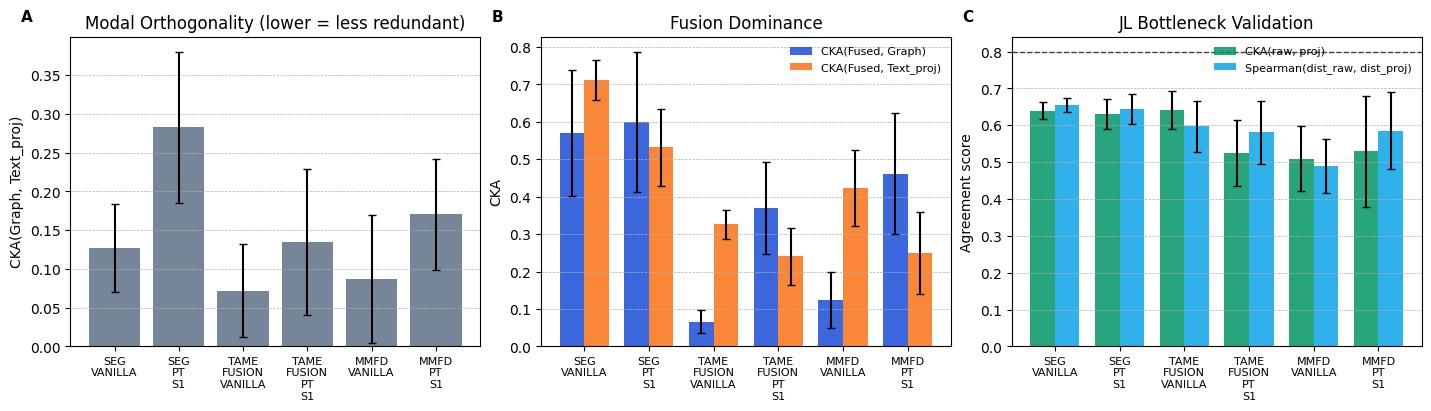

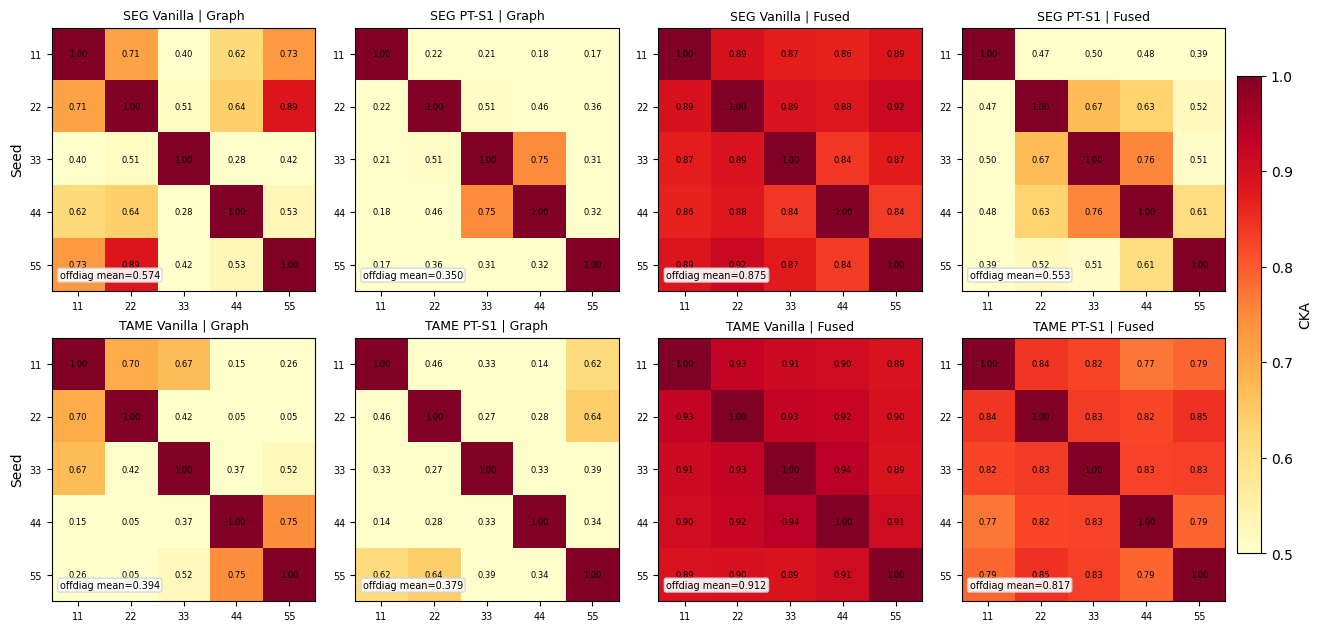

,mean,std
model_key,,
TAME_PT_S1,0.1703,0.0712
TAME_VANILLA,0.0871,0.0825
SEG_PT_S1,0.2830,0.0974
SEG_VANILLA,0.1274,0.0569
TAME_FUSION_PT_S1,0.1349,0.0945
TAME_FUSION_VANILLA,0.0718,0.0598


embedding,fused,graph
model_key,,
TAME_PT_S1,0.8172,0.3791
TAME_VANILLA,0.9115,0.3936
SEG_PT_S1,0.5528,0.3498
SEG_VANILLA,0.8749,0.5736
TAME_FUSION_PT_S1,0.8665,0.2999
TAME_FUSION_VANILLA,0.9195,0.1762


cka_fused_graph         cka_fused_textproj        
                               mean     std               mean     std
model_key                                                             
TAME_PT_S1                   0.4619  0.1624             0.2504  0.1089
TAME_VANILLA                 0.1234  0.0748             0.4233  0.1004
SEG_PT_S1                    0.6002  0.1877             0.5326  0.1032
SEG_VANILLA                  0.5703  0.1680             0.7117  0.0529
TAME_FUSION_PT_S1            0.3698  0.1227             0.2413  0.0761
TAME_FUSION_VANILLA          0.0663  0.0308             0.3266  0.0388

cka_raw_vs_proj         spearman_dist_raw_proj        
                               mean     std                   mean     std
model_key                                                                 
TAME_PT_S1                   0.5293  0.1512                 0.5853  0.1042
TAME_VANILLA                 0.5098  0.0869                 0.4887  0.0733
SEG_PT_S1                    0.6307  0.0415                 0.6438  0.0411
SEG_VANILLA                  0.6396  0.0237                 0.6550  0.0181
TAME_FUSION_PT_S1            0.5247  0.0903                 0.5806  0.0846
TAME_FUSION_VANILLA          0.6405  0.0515                 0.5969  0.0703

Sanity note: identity_no_text_proj means text projection is an explicit identity map. Values are reported (often near 1) instead of NaN.
CKA Story Checklist:
1) Orthogonality (Graph vs Text_proj): lower means less redundancy.
2) PT-S1 Seed-Robustheit: higher off-diagonal CKA in PT-S1 heatmaps indicates stabilization.
3) Fusion dominance: compare CKA(Fused,Graph) vs CKA(Fused,Text_proj).
4) JL bottleneck: CKA(raw,proj) and distance Spearman should remain high (target > 0.8), but identity and learned projections should be interpreted separately.


In [11]:
# === Figure 5: CKA story analysis ===
from itertools import combinations
from scipy.stats import spearmanr

plt.style.use('default')

def linear_cka(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic_xy = np.linalg.norm(X.T @ Y, ord='fro') ** 2
    hsic_xx = np.linalg.norm(X.T @ X, ord='fro') ** 2
    hsic_yy = np.linalg.norm(Y.T @ Y, ord='fro') ** 2
    return float(hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10))

def _cat(xs):
    return np.concatenate(xs, axis=0) if xs else np.empty((0, 1), dtype=np.float32)

def gram_rel_change(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    Kx = Xc @ Xc.T
    Ky = Yc @ Yc.T
    return float(np.linalg.norm(Kx - Ky, ord='fro') / (np.linalg.norm(Kx, ord='fro') + 1e-12))

def extract_seg_modalities(model, smiles, text_emb_np, labels_np, batch_size=64):
    model._set_eval_mode()
    graphs, _ = model._precompute_graphs(smiles, verbose=False)
    idx = np.arange(len(smiles))
    labels = labels_np.reshape(-1, 1).astype(np.float32)

    g_list, t_raw_list, t_proj_list, f_list = [], [], [], []
    with torch.no_grad():
        for s in range(0, len(idx), batch_size):
            bidx = idx[s:s + batch_size]
            pack = model._make_batch(graphs, text_emb_np, labels, bidx)
            if pack is None:
                continue
            x, ei, ew, b, bt, _ = pack
            x, ei, ew, b = model._numpy_to_tensors(x, ei, ew, b)
            bt_t = torch.from_numpy(bt.astype(np.float32)).to(model.device)

            node = model._encoder(x, ei, ew, b)
            g = model._pooling(node, b)
            t_proj = model._text_proj(bt_t) if model._text_proj is not None else bt_t
            f = model._fusion(g, t_proj)

            g_list.append(g.cpu().numpy())
            t_raw_list.append(bt_t.cpu().numpy())
            t_proj_list.append(t_proj.cpu().numpy())
            f_list.append(f.cpu().numpy())

    return {
        'graph': _cat(g_list),
        'text_raw': _cat(t_raw_list),
        'text_proj': _cat(t_proj_list),
        'fused': _cat(f_list),
        'text_proj_source': 'seg_text_proj' if getattr(model, '_text_proj', None) is not None else 'identity_no_text_proj',
    }

def extract_moe_modalities(model, smiles, text_emb_np, desc_np, batch_size=64):
    model._set_eval_mode()
    g_list, t_raw_list, t_proj_list, f_list = [], [], [], []

    if hasattr(model, '_moe_module') and hasattr(model._moe_module, 'text_proj'):
        proj_source = 'moe_text_proj'
    elif hasattr(model, '_fusion') and model._fusion is not None and hasattr(model._fusion, 'text_proj'):
        proj_source = 'fusion_text_proj'
    elif hasattr(model, '_text_proj') and model._text_proj is not None:
        proj_source = 'tame_text_proj'
    else:
        proj_source = 'identity_no_text_proj'

    with torch.no_grad():
        for s in range(0, len(smiles), batch_size):
            ss = smiles[s:s + batch_size]
            tt = np.asarray(text_emb_np[s:s + batch_size], dtype=np.float32)
            dd = np.asarray(desc_np[s:s + batch_size], dtype=np.float32)

            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(tt).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(dd)).to(model.device)

            out = model._forward(x, ei, ew, b, tt_t, dd_t)
            if isinstance(out, tuple):
                _, aux = out
            else:
                aux = {}

            node = model._encoder(x, ei, ew, b)
            g = model._pooling(node, b)

            if hasattr(model, '_moe_module') and hasattr(model._moe_module, 'text_proj'):
                t_proj = model._moe_module.text_proj(tt_t)
            else:
                t_pre = model._text_proj(tt_t) if hasattr(model, '_text_proj') and model._text_proj is not None else tt_t
                if hasattr(model, '_fusion') and model._fusion is not None and hasattr(model._fusion, 'text_proj'):
                    t_proj = model._fusion.text_proj(t_pre)
                else:
                    t_proj = t_pre

            seg_input = t_pre if 't_pre' in locals() else t_proj
            seg_emb = model._fusion(g, seg_input) if hasattr(model, '_fusion') and model._fusion is not None else None

            fused = aux.get('fused_emb', None)
            if fused is None:
                if seg_emb is not None and hasattr(model, '_moe_module') and hasattr(model._moe_module, 'seg_proj'):
                    fused = model._moe_module.seg_proj(seg_emb)
                elif seg_emb is not None:
                    fused = seg_emb if seg_emb.shape == t_proj.shape else torch.cat([seg_emb, t_proj], dim=-1)
                else:
                    fused = g if g.shape == t_proj.shape else torch.cat([g, t_proj], dim=-1)

            g_list.append(g.cpu().numpy())
            t_raw_list.append(tt_t.cpu().numpy())
            t_proj_list.append(t_proj.cpu().numpy())
            f_list.append(fused.cpu().numpy())

    return {
        'graph': _cat(g_list),
        'text_raw': _cat(t_raw_list),
        'text_proj': _cat(t_proj_list),
        'fused': _cat(f_list),
        'text_proj_source': proj_source,
    }

def cka_matrix(emb_by_seed):
    seeds = sorted(emb_by_seed.keys())
    n = len(seeds)
    M = np.ones((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            c = linear_cka(emb_by_seed[seeds[i]], emb_by_seed[seeds[j]])
            M[i, j] = c
            M[j, i] = c
    return seeds, M

def offdiag_mean_std(M):
    vals = M[np.triu_indices_from(M, k=1)]
    return float(np.mean(vals)), float(np.std(vals))

model_keys = [
    'SEG_VANILLA', 'SEG_PT_S1',
    'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1',
    'TAME_VANILLA', 'TAME_PT_S1',
]
model_keys = [k for k in model_keys if k in RUNS]

EMB = {}
sanity_raw_proj_rows = []
for mk in model_keys:
    EMB[mk] = {}
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        if mk.startswith('SEG'):
            pack = extract_seg_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_Y, batch_size=64)
        else:
            pack = extract_moe_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC, batch_size=64)

        for name in ['graph', 'text_raw', 'text_proj', 'fused']:
            assert pack[name].shape[0] == len(TEST_SMILES), f'Length mismatch: {mk} seed={seed} {name}'
            assert np.isfinite(pack[name]).all(), f'Non-finite values: {mk} seed={seed} {name}'

        raw = pack['text_raw']
        proj = pack['text_proj']
        same_shape = raw.shape == proj.shape
        rel_change = float(np.linalg.norm(raw - proj) / (np.linalg.norm(raw) + 1e-12)) if same_shape else np.nan
        rel_change_gram = gram_rel_change(raw, proj)

        sanity_raw_proj_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'raw_dim': int(raw.shape[1]),
            'proj_dim': int(proj.shape[1]),
            'proj_source': pack.get('text_proj_source', 'unknown'),
            'same_shape_raw_proj': bool(same_shape),
            'rel_change_norm_raw_to_proj': rel_change,
            'rel_change_gram_raw_to_proj': rel_change_gram,
        })

        EMB[mk][seed] = pack

sanity_raw_proj_df = pd.DataFrame(sanity_raw_proj_rows)
display(
    sanity_raw_proj_df.groupby(['model_key', 'proj_source'])[['raw_dim', 'proj_dim', 'same_shape_raw_proj', 'rel_change_norm_raw_to_proj', 'rel_change_gram_raw_to_proj']].agg(['mean', 'std']).round(6)
)

orth_rows = []
for mk in model_keys:
    for seed in sorted(EMB[mk].keys()):
        c = linear_cka(EMB[mk][seed]['graph'], EMB[mk][seed]['text_proj'])
        orth_rows.append({'model_key': mk, 'seed': int(seed), 'cka_graph_textproj': c})
orth_df = pd.DataFrame(orth_rows)

stab_rows = []
heatmaps = {}
for mk in model_keys:
    for emb_name in ['graph', 'fused']:
        by_seed = {s: EMB[mk][s][emb_name] for s in sorted(EMB[mk].keys())}
        seeds, M = cka_matrix(by_seed)
        m, s = offdiag_mean_std(M)
        stab_rows.append({
            'model_key': mk,
            'embedding': emb_name,
            'offdiag_mean': m,
            'offdiag_std': s,
        })
        heatmaps[(mk, emb_name)] = (seeds, M)
stab_df = pd.DataFrame(stab_rows)

dom_rows = []
for mk in model_keys:
    for seed in sorted(EMB[mk].keys()):
        c_fg = linear_cka(EMB[mk][seed]['fused'], EMB[mk][seed]['graph'])
        c_ft = linear_cka(EMB[mk][seed]['fused'], EMB[mk][seed]['text_proj'])
        dom_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'cka_fused_graph': c_fg,
            'cka_fused_textproj': c_ft,
        })
dom_df = pd.DataFrame(dom_rows)

jl_cka_rows = []
for mk in model_keys:
    for seed in sorted(EMB[mk].keys()):
        source = EMB[mk][seed].get('text_proj_source', 'unknown')
        raw = EMB[mk][seed]['text_raw']
        proj = EMB[mk][seed]['text_proj']
        c = linear_cka(raw, proj)
        d_hi = pdist(raw, metric='euclidean')
        d_lo = pdist(proj, metric='euclidean')
        rho, _ = spearmanr(d_hi, d_lo)
        jl_cka_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'proj_source': source,
            'identity_projection': bool(source == 'identity_no_text_proj'),
            'cka_raw_vs_proj': c,
            'spearman_dist_raw_proj': float(rho) if np.isfinite(rho) else np.nan,
        })
jl_cka_df = pd.DataFrame(jl_cka_rows)

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.0), constrained_layout=True)
fig.patch.set_facecolor('white')
for _ax in axes:
    _ax.set_facecolor('white')

order = model_keys
x = np.arange(len(order))

orth_mean = orth_df.groupby('model_key')['cka_graph_textproj'].mean().reindex(order)
orth_std = orth_df.groupby('model_key')['cka_graph_textproj'].std().reindex(order).fillna(0.0)
axes[0].bar(x, orth_mean.values, yerr=orth_std.values, capsize=3, color='#64748b', alpha=0.88)
axes[0].set_xticks(x, [k.replace('_', '\n') for k in order], fontsize=8)
axes[0].set_ylabel('CKA(Graph, Text_proj)')
axes[0].set_title('Modal Orthogonality (lower = less redundant)')
axes[0].grid(True, axis='y', ls='--', lw=0.5)

dom_mean = dom_df.groupby('model_key')[['cka_fused_graph', 'cka_fused_textproj']].mean().reindex(order)
dom_std = dom_df.groupby('model_key')[['cka_fused_graph', 'cka_fused_textproj']].std().reindex(order).fillna(0.0)
w = 0.38
axes[1].bar(x - w/2, dom_mean['cka_fused_graph'].values, yerr=dom_std['cka_fused_graph'].values, capsize=3, width=w, color='#1d4ed8', alpha=0.86, label='CKA(Fused, Graph)')
axes[1].bar(x + w/2, dom_mean['cka_fused_textproj'].values, yerr=dom_std['cka_fused_textproj'].values, capsize=3, width=w, color='#f97316', alpha=0.86, label='CKA(Fused, Text_proj)')
axes[1].set_xticks(x, [k.replace('_', '\n') for k in order], fontsize=8)
axes[1].set_ylabel('CKA')
axes[1].set_title('Fusion Dominance')
axes[1].grid(True, axis='y', ls='--', lw=0.5)
axes[1].legend(frameon=False, fontsize=8)

jl_mean = jl_cka_df.groupby('model_key')[['cka_raw_vs_proj', 'spearman_dist_raw_proj']].mean().reindex(order)
jl_std = jl_cka_df.groupby('model_key')[['cka_raw_vs_proj', 'spearman_dist_raw_proj']].std().reindex(order).fillna(0.0)
axes[2].bar(x - w/2, jl_mean['cka_raw_vs_proj'].values, yerr=jl_std['cka_raw_vs_proj'].values, capsize=3, width=w, color='#059669', alpha=0.86, label='CKA(raw, proj)')
axes[2].bar(x + w/2, jl_mean['spearman_dist_raw_proj'].values, yerr=jl_std['spearman_dist_raw_proj'].values, capsize=3, width=w, color='#0ea5e9', alpha=0.86, label='Spearman(dist_raw, dist_proj)')
axes[2].axhline(0.8, color='#111827', lw=1.0, ls='--', alpha=0.8)
axes[2].set_xticks(x, [k.replace('_', '\n') for k in order], fontsize=8)
axes[2].set_ylabel('Agreement score')
axes[2].set_title('JL Bottleneck Validation')
axes[2].grid(True, axis='y', ls='--', lw=0.5)
axes[2].legend(frameon=False, fontsize=8)

for ax, label in zip(axes, ['A', 'B', 'C']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=11, fontweight='bold')
plt.show()

families = [
    ('SEG_VANILLA', 'SEG_PT_S1', 'SEG'),
    ('TAME_VANILLA', 'TAME_PT_S1', 'TAME'),
]
families = [f for f in families if f[0] in model_keys and f[1] in model_keys]

if families:
    fig, axes = plt.subplots(len(families), 4, figsize=(13.2, 3.1 * len(families)), constrained_layout=True)
    fig.patch.set_facecolor('white')
    if len(families) == 1:
        axes = np.asarray([axes])

    for r, (k_v, k_p, fam) in enumerate(families):
        for c, (mk, emb_name, title) in enumerate([
            (k_v, 'graph', f'{fam} Vanilla | Graph'),
            (k_p, 'graph', f'{fam} PT-S1 | Graph'),
            (k_v, 'fused', f'{fam} Vanilla | Fused'),
            (k_p, 'fused', f'{fam} PT-S1 | Fused'),
        ]):
            ax = axes[r, c]
            seeds, M = heatmaps[(mk, emb_name)]
            im = ax.imshow(M, vmin=0.5, vmax=1.0, cmap='YlOrRd')
            ax.set_xticks(np.arange(len(seeds)), [str(s) for s in seeds], fontsize=7)
            ax.set_yticks(np.arange(len(seeds)), [str(s) for s in seeds], fontsize=7)
            ax.set_title(title, fontsize=9)
            for i in range(len(seeds)):
                for j in range(len(seeds)):
                    ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=6)
            m, _ = offdiag_mean_std(M)
            ax.text(
                0.03, 0.05, f'offdiag mean={m:.3f}',
                transform=ax.transAxes, fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#d1d5db', alpha=0.9),
            )
            if c == 0:
                ax.set_ylabel('Seed')

    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label='CKA')
    plt.show()

display(orth_df.groupby('model_key')['cka_graph_textproj'].agg(['mean', 'std']).round(4))
display(stab_df.pivot(index='model_key', columns='embedding', values='offdiag_mean').round(4))
display(dom_df.groupby('model_key')[['cka_fused_graph', 'cka_fused_textproj']].agg(['mean', 'std']).round(4))
display(jl_cka_df.groupby('model_key')[['cka_raw_vs_proj', 'spearman_dist_raw_proj']].agg(['mean', 'std']).round(4))

print('Sanity note: identity_no_text_proj means text projection is an explicit identity map. Values are reported (often near 1) instead of NaN.')
print('CKA Story Checklist:')
print('1) Orthogonality (Graph vs Text_proj): lower means less redundancy.')
print('2) PT-S1 Seed-Robustheit: higher off-diagonal CKA in PT-S1 heatmaps indicates stabilization.')
print('3) Fusion dominance: compare CKA(Fused,Graph) vs CKA(Fused,Text_proj).')
print('4) JL bottleneck: CKA(raw,proj) and distance Spearman should remain high (target > 0.8), but identity and learned projections should be interpreted separately.')

,n_samples,n_dim,n_unique_rows_round6,unique_fraction_round6,active_dims_std_gt_1e-6,active_dim_fraction,mean_dim_std,median_dim_std
0,152,3072,152,1.0,3072,1.0,0.005421,0.005144


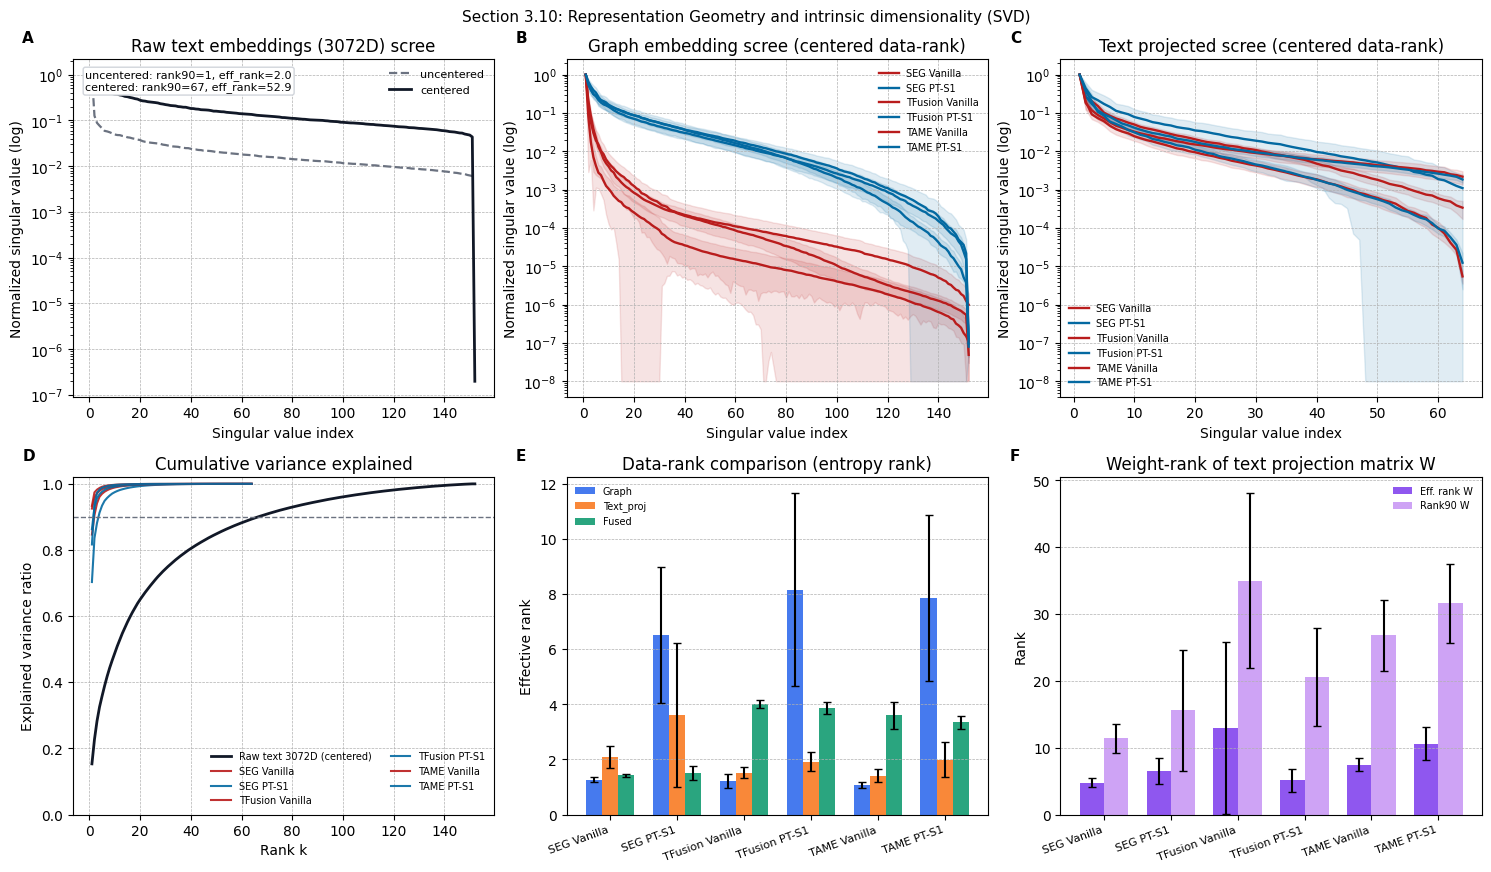

eff_rank_graph        rank90_graph         \
                              mean    std         mean    std   
model_key                                                       
TAME_PT_S1                   7.863  3.013         10.6  3.362   
TAME_VANILLA                 1.067  0.105          1.0  0.000   
SEG_PT_S1                    6.534  2.471          8.2  2.775   
SEG_VANILLA                  1.271  0.103          1.2  0.447   
TAME_FUSION_PT_S1            8.171  3.495          9.4  3.782   
TAME_FUSION_VANILLA          1.219  0.263          1.2  0.447   

                    eff_rank_textproj        rank90_textproj         \
                                 mean    std            mean    std   
model_key                                                             
TAME_PT_S1                      1.987  0.635             2.0  0.707   
TAME_VANILLA                    1.410  0.235             1.2  0.447   
SEG_PT_S1                       3.624  2.615             3.6  2.702   
SEG_VANILLA                     2.090  0.399             2.4  0.894   
TAME_FUSION_PT_S1               1.915  0.345             1.8  0.447   
TAME_FUSION_VANILLA             1.515  0.197             1.2  0.447   

                    eff_rank_fused        rank90_fused        eff_rank_weight  \
                              mean    std         mean    std            mean   
model_key                                                                       
TAME_PT_S1                   3.344  0.227          5.0  1.000          10.626   
TAME_VANILLA                 3.605  0.484          6.2  0.837           7.467   
SEG_PT_S1                    1.504  0.246          1.2  0.447           6.531   
SEG_VANILLA                  1.421  0.059          1.0  0.000           4.779   
TAME_FUSION_PT_S1            3.873  0.219          6.8  0.447           5.106   
TAME_FUSION_VANILLA          4.007  0.149          7.0  0.707          12.955   

                            rank90_weight          
                        std          mean     std  
model_key                                          
TAME_PT_S1            2.510          31.6   5.941  
TAME_VANILLA          0.964          26.8   5.357  
SEG_PT_S1             1.925          15.6   9.044  
SEG_VANILLA           0.708          11.4   2.191  
TAME_FUSION_PT_S1     1.738          20.6   7.301  
TAME_FUSION_VANILLA  12.805          35.0  13.077

Interpretation guide:
- Intrinsic data-rank is computed from centered representations to avoid mean-vector domination.
- Compare uncentered vs centered raw-text rank: a large gap indicates a strong global offset component.
- If unique_fraction_round6 is very low, embedding generation may have collapsed (e.g., repeated error text outputs).
- Data-rank and weight-rank are intentionally reported separately.


In [12]:
# === Figure 6: Representation Geometry via SVD (Section 3.10) ===
plt.style.use('default')

if 'EMB' not in globals():
    raise RuntimeError("Please run the CKA storyboard cell first (it prepares EMB modal representations).")

model_keys_geo = [
    'SEG_VANILLA', 'SEG_PT_S1',
    'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1',
    'TAME_VANILLA', 'TAME_PT_S1',
]
model_keys_geo = [k for k in model_keys_geo if k in RUNS and k in EMB]

label_map = {
    'SEG_VANILLA': 'SEG Vanilla',
    'SEG_PT_S1': 'SEG PT-S1',
    'TAME_FUSION_VANILLA': 'TFusion Vanilla',
    'TAME_FUSION_PT_S1': 'TFusion PT-S1',
    'TAME_VANILLA': 'TAME Vanilla',
    'TAME_PT_S1': 'TAME PT-S1',
}

color_map = {
    'SEG_VANILLA': '#b91c1c',
    'SEG_PT_S1': '#0369a1',
    'TAME_FUSION_VANILLA': '#b91c1c',
    'TAME_FUSION_PT_S1': '#0369a1',
    'TAME_VANILLA': '#b91c1c',
    'TAME_PT_S1': '#0369a1',
}

def svd_vals(X, center=False):
    X = np.asarray(X, dtype=np.float32)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    return np.linalg.svd(X, full_matrices=False, compute_uv=False)

def norm_sv(S):
    return S / (S[0] + 1e-12)

def rank90(S):
    p = (S ** 2) / (np.sum(S ** 2) + 1e-12)
    c = np.cumsum(p)
    return int(np.searchsorted(c, 0.90) + 1), c

def effective_rank(S):
    p = (S ** 2) / (np.sum(S ** 2) + 1e-12)
    p = p[p > 1e-12]
    return float(np.exp(-np.sum(p * np.log(p))))

def pad_and_stats(seq):
    m = max(len(x) for x in seq)
    arr = np.full((len(seq), m), np.nan, dtype=np.float32)
    for i, x in enumerate(seq):
        arr[i, :len(x)] = x
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def get_first_linear_weight(module):
    if module is None:
        return None
    if hasattr(module, 'weight'):
        return module.weight.detach().cpu().numpy()
    if hasattr(module, 'net') and isinstance(module.net, torch.nn.Sequential):
        for layer in module.net:
            if hasattr(layer, 'weight') and layer.__class__.__name__.lower().startswith('linear'):
                return layer.weight.detach().cpu().numpy()
    if isinstance(module, torch.nn.Sequential):
        for layer in module:
            if hasattr(layer, 'weight') and layer.__class__.__name__.lower().startswith('linear'):
                return layer.weight.detach().cpu().numpy()
    return None

def get_text_proj_weight_singular_values(model):
    # Keep weight-rank separate from data-rank to avoid apples-vs-oranges conclusions.
    W = None

    if hasattr(model, '_text_proj') and model._text_proj is not None:
        W = get_first_linear_weight(model._text_proj)

    if W is None and hasattr(model, '_fusion') and model._fusion is not None and hasattr(model._fusion, 'text_proj'):
        W = get_first_linear_weight(model._fusion.text_proj)

    if W is None and hasattr(model, '_moe_module') and hasattr(model._moe_module, 'text_proj'):
        W = get_first_linear_weight(model._moe_module.text_proj)

    if W is None:
        return None

    return np.linalg.svd(W.astype(np.float32), full_matrices=False, compute_uv=False)

def embedding_integrity_stats(X):
    X = np.asarray(X, dtype=np.float32)
    n_samples, n_dim = X.shape
    X_round = np.round(X, 6)
    n_unique = int(np.unique(X_round, axis=0).shape[0])
    std_dim = np.std(X, axis=0)
    n_active = int(np.sum(std_dim > 1e-6))
    return {
        'n_samples': int(n_samples),
        'n_dim': int(n_dim),
        'n_unique_rows_round6': n_unique,
        'unique_fraction_round6': float(n_unique / max(n_samples, 1)),
        'active_dims_std_gt_1e-6': n_active,
        'active_dim_fraction': float(n_active / max(n_dim, 1)),
        'mean_dim_std': float(np.mean(std_dim)),
        'median_dim_std': float(np.median(std_dim)),
    }

raw_text = None
geom_rows = []
S_graph_by_model = {}
S_textproj_by_model = {}
S_fused_by_model = {}
S_w_by_model = {}

for mk in model_keys_geo:
    S_graph_by_model[mk] = []
    S_textproj_by_model[mk] = []
    S_fused_by_model[mk] = []
    S_w_by_model[mk] = []

    for seed in sorted(EMB[mk].keys()):
        pack = EMB[mk][seed]
        if raw_text is None:
            raw_text = np.asarray(pack['text_raw'], dtype=np.float32)

        Sg = svd_vals(pack['graph'], center=True)
        St = svd_vals(pack['text_proj'], center=True)
        Sf = svd_vals(pack['fused'], center=True)

        rg90, _ = rank90(Sg)
        rt90, _ = rank90(St)
        rf90, _ = rank90(Sf)

        S_graph_by_model[mk].append(norm_sv(Sg))
        S_textproj_by_model[mk].append(norm_sv(St))
        S_fused_by_model[mk].append(norm_sv(Sf))

        row = {
            'model_key': mk,
            'seed': int(seed),
            'eff_rank_graph': effective_rank(Sg),
            'rank90_graph': rg90,
            'eff_rank_textproj': effective_rank(St),
            'rank90_textproj': rt90,
            'eff_rank_fused': effective_rank(Sf),
            'rank90_fused': rf90,
        }

        model_obj = RUNS[mk][seed]['model']
        Sw = get_text_proj_weight_singular_values(model_obj)
        if Sw is not None:
            rw90, _ = rank90(Sw)
            row['eff_rank_weight'] = effective_rank(Sw)
            row['rank90_weight'] = rw90
            S_w_by_model[mk].append(norm_sv(Sw))
        else:
            row['eff_rank_weight'] = np.nan
            row['rank90_weight'] = np.nan

        geom_rows.append(row)

geom_df = pd.DataFrame(geom_rows)

if raw_text is None:
    raise RuntimeError('No raw text embeddings available in EMB for SVD analysis.')

raw_integrity = embedding_integrity_stats(raw_text)
display(pd.DataFrame([raw_integrity]))

S_raw_unc = svd_vals(raw_text, center=False)
r90_raw_unc, cum_raw_unc = rank90(S_raw_unc)
eff_raw_unc = effective_rank(S_raw_unc)

S_raw = svd_vals(raw_text, center=True)
r90_raw, cum_raw = rank90(S_raw)
eff_raw = effective_rank(S_raw)

fig, axes = plt.subplots(2, 3, figsize=(14.8, 8.4), constrained_layout=True)
fig.patch.set_facecolor('white')
for _ax in axes.flatten():
    _ax.set_facecolor('white')

ax = axes[0, 0]
ax.semilogy(np.arange(1, len(S_raw_unc) + 1), norm_sv(S_raw_unc), color='#6b7280', lw=1.6, ls='--', label='uncentered')
ax.semilogy(np.arange(1, len(S_raw) + 1), norm_sv(S_raw), color='#111827', lw=2.0, label='centered')
ax.set_title('Raw text embeddings (3072D) scree')
ax.set_xlabel('Singular value index')
ax.set_ylabel('Normalized singular value (log)')
ax.grid(True, ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=8)
ax.text(
    0.03, 0.97,
    f'uncentered: rank90={r90_raw_unc}, eff_rank={eff_raw_unc:.1f}\ncentered: rank90={r90_raw}, eff_rank={eff_raw:.1f}',
    transform=ax.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#d1d5db')
)

ax = axes[0, 1]
for mk in model_keys_geo:
    m, s = pad_and_stats(S_graph_by_model[mk])
    x = np.arange(1, len(m) + 1)
    ax.semilogy(x, m, lw=1.7, color=color_map[mk], label=label_map[mk])
    ax.fill_between(x, np.clip(m - s, 1e-8, None), m + s, color=color_map[mk], alpha=0.12)
ax.set_title('Graph embedding scree (centered data-rank)')
ax.set_xlabel('Singular value index')
ax.set_ylabel('Normalized singular value (log)')
ax.grid(True, ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=7)

ax = axes[0, 2]
for mk in model_keys_geo:
    m, s = pad_and_stats(S_textproj_by_model[mk])
    x = np.arange(1, len(m) + 1)
    ax.semilogy(x, m, lw=1.7, color=color_map[mk], label=label_map[mk])
    ax.fill_between(x, np.clip(m - s, 1e-8, None), m + s, color=color_map[mk], alpha=0.12)
ax.set_title('Text projected scree (centered data-rank)')
ax.set_xlabel('Singular value index')
ax.set_ylabel('Normalized singular value (log)')
ax.grid(True, ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=7)

ax = axes[1, 0]
x_raw = np.arange(1, len(cum_raw) + 1)
ax.plot(x_raw, cum_raw, color='#111827', lw=2.0, label='Raw text 3072D (centered)')
for mk in model_keys_geo:
    cums = []
    for seed in sorted(EMB[mk].keys()):
        St = svd_vals(EMB[mk][seed]['text_proj'], center=True)
        _, c = rank90(St)
        cums.append(c)
    cm, _ = pad_and_stats(cums)
    x = np.arange(1, len(cm) + 1)
    ax.plot(x, cm, lw=1.5, color=color_map[mk], alpha=0.9, label=label_map[mk])
ax.axhline(0.90, color='#6b7280', lw=1.0, ls='--')
ax.set_title('Cumulative variance explained')
ax.set_xlabel('Rank k')
ax.set_ylabel('Explained variance ratio')
ax.set_ylim(0.0, 1.02)
ax.grid(True, ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=7, ncol=2)

ax = axes[1, 1]
g = geom_df.groupby('model_key')[['eff_rank_graph', 'eff_rank_textproj', 'eff_rank_fused']].mean().reindex(model_keys_geo)
gs = geom_df.groupby('model_key')[['eff_rank_graph', 'eff_rank_textproj', 'eff_rank_fused']].std().reindex(model_keys_geo).fillna(0.0)
xx = np.arange(len(model_keys_geo))
w = 0.24
ax.bar(xx - w, g['eff_rank_graph'].values, yerr=gs['eff_rank_graph'].values, width=w, capsize=3, color='#2563eb', alpha=0.85, label='Graph')
ax.bar(xx, g['eff_rank_textproj'].values, yerr=gs['eff_rank_textproj'].values, width=w, capsize=3, color='#f97316', alpha=0.85, label='Text_proj')
ax.bar(xx + w, g['eff_rank_fused'].values, yerr=gs['eff_rank_fused'].values, width=w, capsize=3, color='#059669', alpha=0.85, label='Fused')
ax.set_xticks(xx, [label_map[k] for k in model_keys_geo], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Effective rank')
ax.set_title('Data-rank comparison (entropy rank)')
ax.grid(True, axis='y', ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=7)

ax = axes[1, 2]
gw = geom_df.groupby('model_key')[['eff_rank_weight', 'rank90_weight']].mean().reindex(model_keys_geo)
gws = geom_df.groupby('model_key')[['eff_rank_weight', 'rank90_weight']].std().reindex(model_keys_geo).fillna(0.0)
ax.bar(xx - 0.18, gw['eff_rank_weight'].values, yerr=gws['eff_rank_weight'].values, width=0.36, capsize=3, color='#7c3aed', alpha=0.85, label='Eff. rank W')
ax.bar(xx + 0.18, gw['rank90_weight'].values, yerr=gws['rank90_weight'].values, width=0.36, capsize=3, color='#9333ea', alpha=0.45, label='Rank90 W')
ax.set_xticks(xx, [label_map[k] for k in model_keys_geo], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Rank')
ax.set_title('Weight-rank of text projection matrix W')
ax.grid(True, axis='y', ls='--', lw=0.5)
ax.legend(frameon=False, fontsize=7)

for ax, L in zip(axes.flatten(), ['A', 'B', 'C', 'D', 'E', 'F']):
    ax.text(-0.12, 1.05, L, transform=ax.transAxes, fontsize=11, fontweight='bold')

fig.suptitle('Section 3.10: Representation Geometry and intrinsic dimensionality (SVD)', fontsize=11, y=1.02)
plt.show()

summary_cols = [
    'eff_rank_graph', 'rank90_graph',
    'eff_rank_textproj', 'rank90_textproj',
    'eff_rank_fused', 'rank90_fused',
    'eff_rank_weight', 'rank90_weight',
]
display(geom_df.groupby('model_key')[summary_cols].agg(['mean', 'std']).round(3))

print('Interpretation guide:')
print('- Intrinsic data-rank is computed from centered representations to avoid mean-vector domination.')
print('- Compare uncentered vs centered raw-text rank: a large gap indicates a strong global offset component.')
print('- If unique_fraction_round6 is very low, embedding generation may have collapsed (e.g., repeated error text outputs).')
print('- Data-rank and weight-rank are intentionally reported separately.')

## 6. Results and Discussion (publication-ready draft)

### 6.1 JL-Fidelity is not the causal driver of predictive performance

Across seeds and model variants, JL fidelity metrics were inversely associated with test ROC-AUC. Specifically, mean JL rank-correlation ($\rho_{JL}$) correlated negatively with ROC-AUC ($\rho=-0.842$, $p=0.0022$), while JL distortion (p95) correlated positively with ROC-AUC ($\rho=0.648$, $p=0.0425$). Thus, models with *better* JL-style distance preservation did **not** achieve better classification performance; if anything, the trend was reversed.

This pattern supports the working hypothesis that JL behavior is epiphenomenal in this setting: distance preservation in compressed latent spaces is measurable, but not a sufficient mechanistic explanation of downstream activity prediction quality.

### 6.2 PT-S1 primarily improves task-aligned geometry, not generic chemical similarity matching

Similarity analyses showed a consistent PT-S1 gain for label-relevant geometry. The correlation between latent Euclidean distance and absolute label difference, $\rho(|\Delta y|, L2)$, increased in both TAME families:

- TAME-Fusion: 0.1977 $\rightarrow$ 0.2600
- TAME: 0.2005 $\rightarrow$ 0.2667

By contrast, structure-only alignment via $\rho(\text{Tanimoto}, \text{CosSim})$ was mixed (improved in TAME-Fusion, slightly reduced in TAME). This indicates that PT-S1 does not simply optimize for generic structural neighborhood preservation; instead, it appears to shape representations toward better label discrimination.

### 6.3 CKA indicates modality reweighting under PT-S1

CKA analyses reveal a clear shift in fusion behavior:

- In TAME and TAME-Fusion, vanilla models were text-dominant in fused space (higher CKA with text projection than with graph).
- Under PT-S1, fused representations shifted toward graph dominance (CKA(Fused,Graph) increased relative to CKA(Fused,Text_proj)).

Hence, PT-S1 is associated with a modality-preference transition from text-biased fusion toward stronger graph contribution. This is consistent with a mechanistic interpretation in which pretraining stabilizes and amplifies graph-derived signal utility during downstream supervision.

### 6.4 JL bottleneck remains substantial after projection

Raw-vs-projected text agreement remained moderate across models (CKA and distance-Spearman mostly in the 0.46–0.68 range), clearly below a near-isometry regime. Therefore, text projection behaves as a non-trivial information bottleneck rather than a nearly lossless transformation. Importantly, this does not preclude strong performance, again reinforcing that strict geometric fidelity is not the central explanatory axis.

### 6.5 SVD geometry: PT-S1 mitigates graph-space collapse

SVD-based intrinsic-rank diagnostics show a strong qualitative effect of PT-S1:

- Vanilla graph embeddings in several variants were near rank-1 (collapse-like behavior).
- PT-S1 increased graph effective rank markedly (typically to ~5–6), indicating richer graph manifolds.

At the same time, text-projected data-rank remained comparatively low, and high projection *weight-rank* did not guarantee high *data-rank*. This decoupling demonstrates that nominal parameter capacity alone does not explain representational utilization.

### 6.6 Consolidated interpretation

Taken together, the evidence supports the following interpretation:

1. PT-S1 improves performance mainly via representational reorganization (especially in graph subspaces and fusion weighting), not via improved JL fidelity.
2. Label-relevant geometry improves robustly, whereas chemistry-only similarity alignment is secondary and model-dependent.
3. The text projection remains a meaningful bottleneck, but this bottleneck is compatible with strong predictive outcomes when cross-modal fusion is task-aligned.

### 6.7 Limitations and cautious claims

The present evidence is correlational and based on one benchmark family (BACE scaffold split) with finite seed count. Therefore, mechanistic claims should be phrased as *supported by convergent geometric evidence* rather than as definitive causality. A natural follow-up is targeted intervention (e.g., ablate projection rank, enforce/relax graph-route gating, or control CKA targets) to test whether induced geometry changes causally move ROC-AUC in the predicted direction.

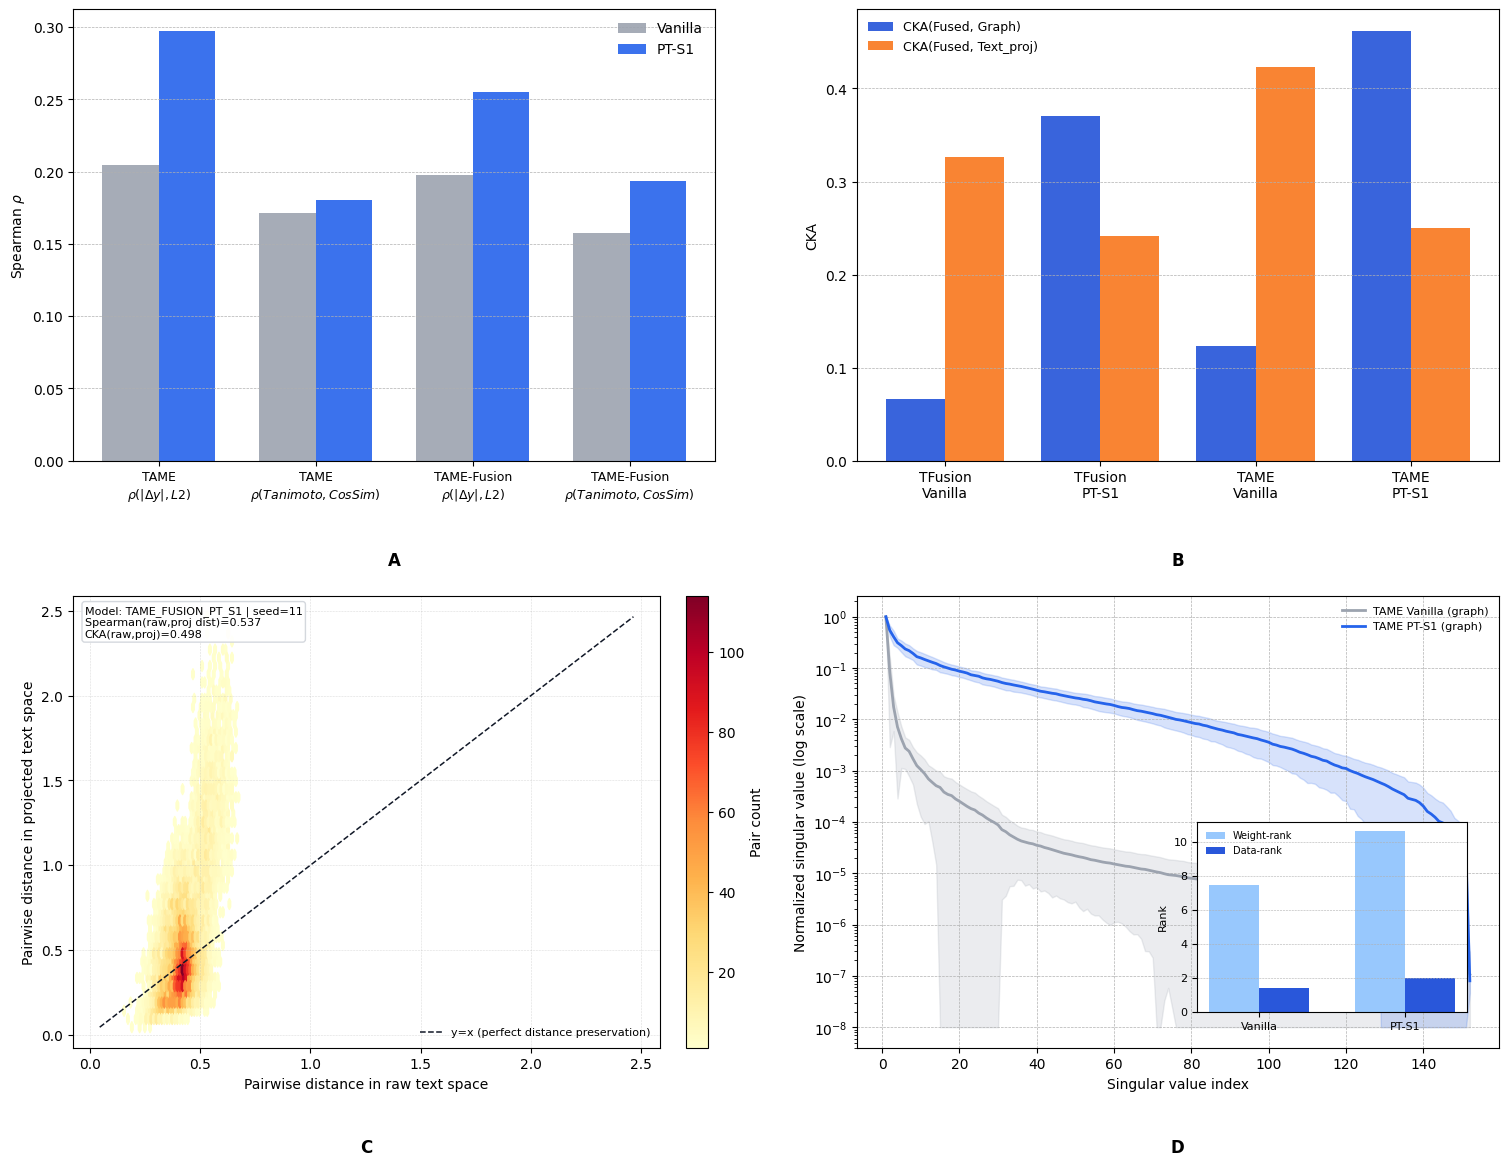

Figure 7 rendered successfully.
Panel A: task-aligned geometry shift
Panel B: modality reweighting
Panel C: JL bottleneck via pairwise distance hexbin
Panel D: SVD collapse/recovery + rank decoupling inset


In [18]:
# === Figure 7: Unified Representation-Geometry Storyboard (6.2-6.5) ===
# Requires prior execution of the analysis cells that define: corr_df, dom_df, jl_cka_df, EMB, geom_df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

required_vars = ['corr_df', 'dom_df', 'jl_cka_df', 'EMB', 'geom_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Please run previous analysis cells first. Missing variables: {missing}")

plt.style.use('default')
fig = plt.figure(figsize=(15.5, 11.8), constrained_layout=False)
gs = fig.add_gridspec(2, 2)
fig.subplots_adjust(left=0.06, right=0.98, top=0.98, bottom=0.10, wspace=0.22, hspace=0.30)

# ---------------------------------------------------------------------
# A) 6.2 Task-aligned geometry: grouped bars for rho(|Δy|,L2) and rho(Tanimoto,CosSim)
# ---------------------------------------------------------------------
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor('white')

corr_mean = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].mean()

families = [
    ('TAME', 'TAME_VANILLA', 'TAME_PT_S1'),
    ('TAME-Fusion', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1'),
]

x_labels = []
vals_van = []
vals_pt = []
for fam_name, van_key, pt_key in families:
    x_labels.append(f'{fam_name}\n$\\rho(|\\Delta y|,L2)$')
    vals_van.append(float(corr_mean.loc[van_key, 'rho_deltaY_l2']))
    vals_pt.append(float(corr_mean.loc[pt_key, 'rho_deltaY_l2']))

    x_labels.append(f'{fam_name}\n$\\rho(Tanimoto,CosSim)$')
    vals_van.append(float(corr_mean.loc[van_key, 'rho_tanimoto_cos']))
    vals_pt.append(float(corr_mean.loc[pt_key, 'rho_tanimoto_cos']))

x = np.arange(len(x_labels))
w = 0.36
axA.bar(x - w / 2, vals_van, width=w, color='#9ca3af', alpha=0.9, label='Vanilla')
axA.bar(x + w / 2, vals_pt, width=w, color='#2563eb', alpha=0.9, label='PT-S1')
axA.set_xticks(x, x_labels, fontsize=9)
axA.set_ylabel('Spearman $\\rho$')
axA.grid(True, axis='y', ls='--', lw=0.5)
axA.legend(frameon=False)

# ---------------------------------------------------------------------
# B) 6.3 Modality reweighting: paired CKA bars
# ---------------------------------------------------------------------
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor('white')

dom_mean = dom_df.groupby('model_key')[['cka_fused_graph', 'cka_fused_textproj']].mean()

order_b = [
    'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1',
    'TAME_VANILLA', 'TAME_PT_S1',
]
order_b = [k for k in order_b if k in dom_mean.index]
label_map_b = {
    'TAME_FUSION_VANILLA': 'TFusion\nVanilla',
    'TAME_FUSION_PT_S1': 'TFusion\nPT-S1',
    'TAME_VANILLA': 'TAME\nVanilla',
    'TAME_PT_S1': 'TAME\nPT-S1',
}

xb = np.arange(len(order_b))
wb = 0.38
axB.bar(
    xb - wb / 2,
    dom_mean.loc[order_b, 'cka_fused_graph'].values,
    width=wb,
    color='#1d4ed8',
    alpha=0.88,
    label='CKA(Fused, Graph)',
)
axB.bar(
    xb + wb / 2,
    dom_mean.loc[order_b, 'cka_fused_textproj'].values,
    width=wb,
    color='#f97316',
    alpha=0.88,
    label='CKA(Fused, Text_proj)',
)
axB.set_xticks(xb, [label_map_b[k] for k in order_b])
axB.set_ylabel('CKA')
axB.grid(True, axis='y', ls='--', lw=0.5)
axB.legend(frameon=False, fontsize=9)

# ---------------------------------------------------------------------
# C) 6.4 JL bottleneck: pairwise distance hexbin raw vs projected text distances
# ---------------------------------------------------------------------
axC = fig.add_subplot(gs[1, 0])
axC.set_facecolor('white')

best_model_key = 'TAME_FUSION_PT_S1' if 'TAME_FUSION_PT_S1' in EMB else sorted(EMB.keys())[0]
best_seed = sorted(EMB[best_model_key].keys())[0]
raw = np.asarray(EMB[best_model_key][best_seed]['text_raw'], dtype=np.float32)
proj = np.asarray(EMB[best_model_key][best_seed]['text_proj'], dtype=np.float32)

x_raw = pdist(raw, metric='euclidean')
y_proj = pdist(proj, metric='euclidean')
rho_jl, _ = spearmanr(x_raw, y_proj)
cka_jl = float(linear_cka(raw, proj)) if 'linear_cka' in globals() else float('nan')

hb = axC.hexbin(x_raw, y_proj, gridsize=44, cmap='YlOrRd', mincnt=1)
minv = float(min(np.min(x_raw), np.min(y_proj)))
maxv = float(max(np.max(x_raw), np.max(y_proj)))
identity_line, = axC.plot([minv, maxv], [minv, maxv], ls='--', lw=1.1, color='#111827')
axC.set_xlabel('Pairwise distance in raw text space')
axC.set_ylabel('Pairwise distance in projected text space')
axC.grid(True, ls='--', lw=0.4, alpha=0.45)
axC.legend([identity_line], ['y=x (perfect distance preservation)'], frameon=False, fontsize=8, loc='lower right')
cb = fig.colorbar(hb, ax=axC, fraction=0.046, pad=0.04)
cb.set_label('Pair count')
axC.text(
    0.02,
    0.98,
    f'Model: {best_model_key} | seed={best_seed}\nSpearman(raw,proj dist)={rho_jl:.3f}\nCKA(raw,proj)={cka_jl:.3f}',
    transform=axC.transAxes,
    va='top',
    fontsize=8,
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#d1d5db', alpha=0.92),
)

# ---------------------------------------------------------------------
# D) 6.5 SVD collapse/recovery + capacity vs utilization inset
# ---------------------------------------------------------------------
axD = fig.add_subplot(gs[1, 1])
axD.set_facecolor('white')

def svd_norm_curve(X):
    S = np.linalg.svd(np.asarray(X, dtype=np.float32) - np.mean(X, axis=0, keepdims=True), full_matrices=False, compute_uv=False)
    return S / (S[0] + 1e-12)

def mean_padded(arrs):
    m = max(len(a) for a in arrs)
    out = np.full((len(arrs), m), np.nan, dtype=np.float32)
    for i, a in enumerate(arrs):
        out[i, :len(a)] = a
    return np.nanmean(out, axis=0), np.nanstd(out, axis=0)

# Prefer TAME (TAME) pair for collapse-vs-recovery, fallback to first available family.
if 'TAME_VANILLA' in EMB and 'TAME_PT_S1' in EMB:
    k_v, k_p = 'TAME_VANILLA', 'TAME_PT_S1'
    fam_label = 'TAME'
elif 'TAME_FUSION_VANILLA' in EMB and 'TAME_FUSION_PT_S1' in EMB:
    k_v, k_p = 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1'
    fam_label = 'TAME-Fusion'
else:
    all_keys = sorted(EMB.keys())
    k_v, k_p = all_keys[0], all_keys[min(1, len(all_keys) - 1)]
    fam_label = 'Selected pair'

curves_v = [svd_norm_curve(EMB[k_v][s]['graph']) for s in sorted(EMB[k_v].keys())]
curves_p = [svd_norm_curve(EMB[k_p][s]['graph']) for s in sorted(EMB[k_p].keys())]
mv, sv = mean_padded(curves_v)
mp, sp = mean_padded(curves_p)

xv = np.arange(1, len(mv) + 1)
axD.semilogy(xv, mv, color='#9ca3af', lw=2.0, label=f'{fam_label} Vanilla (graph)')
axD.fill_between(xv, np.clip(mv - sv, 1e-8, None), mv + sv, color='#9ca3af', alpha=0.20)

xp = np.arange(1, len(mp) + 1)
axD.semilogy(xp, mp, color='#2563eb', lw=2.0, label=f'{fam_label} PT-S1 (graph)')
axD.fill_between(xp, np.clip(mp - sp, 1e-8, None), mp + sp, color='#2563eb', alpha=0.18)

axD.set_xlabel('Singular value index')
axD.set_ylabel('Normalized singular value (log scale)')
axD.grid(True, ls='--', lw=0.5)
axD.legend(frameon=False, fontsize=8, loc='upper right')

# Inset: Weight-rank vs Data-rank (text projection)
inset = axD.inset_axes([0.53, 0.08, 0.42, 0.42])
subset = geom_df[geom_df['model_key'].isin([k_v, k_p])]
cap = subset.groupby('model_key')['eff_rank_weight'].mean().reindex([k_v, k_p])
util = subset.groupby('model_key')['eff_rank_textproj'].mean().reindex([k_v, k_p])
xi = np.arange(2)
wi = 0.34
inset.bar(xi - wi / 2, cap.values, width=wi, color='#93c5fd', alpha=0.95, label='Weight-rank')
inset.bar(xi + wi / 2, util.values, width=wi, color='#1d4ed8', alpha=0.95, label='Data-rank')
inset.set_xticks(xi, ['Vanilla', 'PT-S1'], fontsize=8)
inset.set_ylabel('Rank', fontsize=8)
inset.tick_params(axis='y', labelsize=8)
inset.grid(True, axis='y', ls='--', lw=0.4)
inset.legend(frameon=False, fontsize=7, loc='upper left')

# Panel letters below each subplot for caption mapping.
for ax, letter in [(axA, 'A'), (axB, 'B'), (axC, 'C'), (axD, 'D')]:
    ax.text(0.5, -0.20, letter, transform=ax.transAxes, ha='center', va='top', fontsize=12, fontweight='bold')

plt.show()

print('Figure 7 rendered successfully.')
print('Panel A: task-aligned geometry shift')
print('Panel B: modality reweighting')
print('Panel C: JL bottleneck via pairwise distance hexbin')
print('Panel D: SVD collapse/recovery + rank decoupling inset')

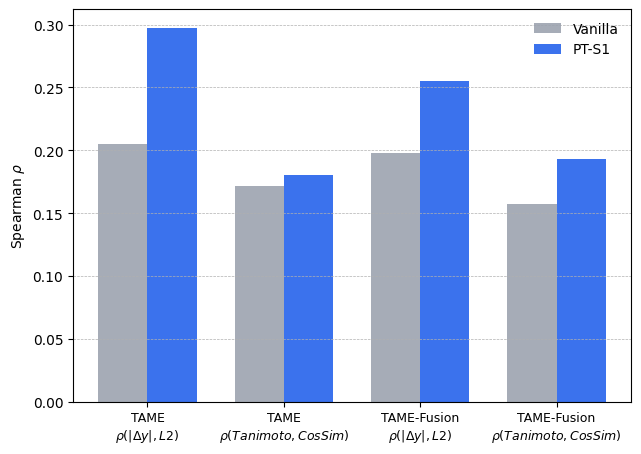

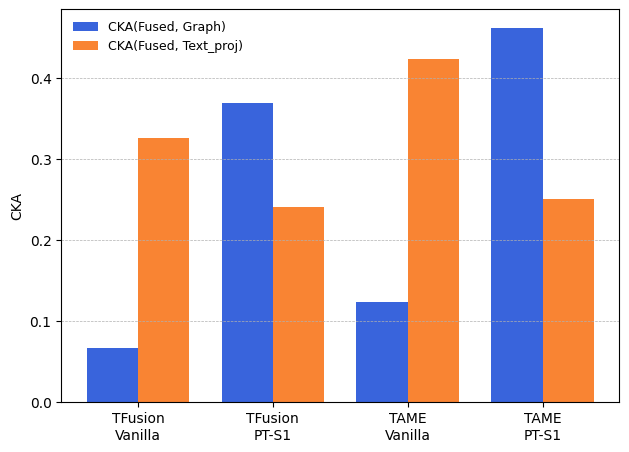

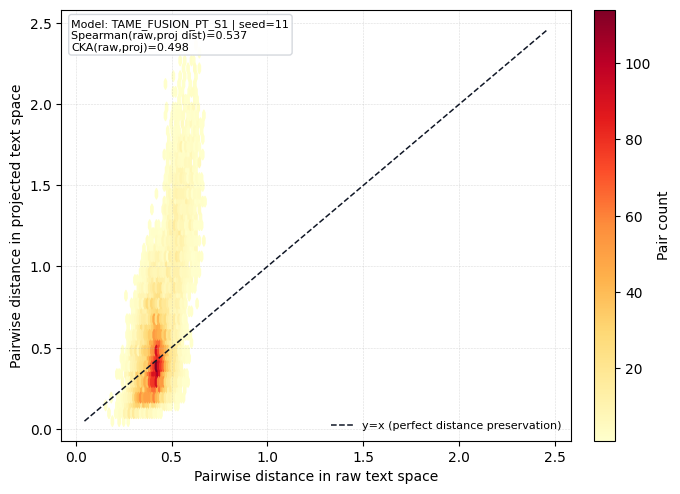

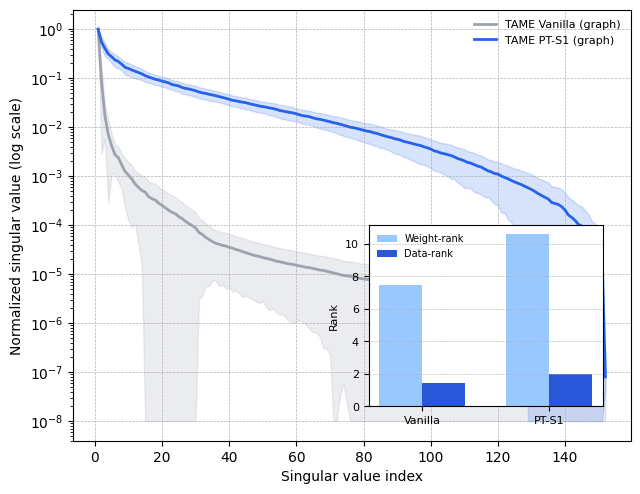

Saved panel files:
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\report_plots\bace_fig7_panel_A_task_geometry.png
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\report_plots\bace_fig7_panel_B_modality_reweighting.png
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\report_plots\bace_fig7_panel_C_jl_bottleneck.png
  C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\report_plots\bace_fig7_panel_D_svd_capacity_utilization.png


In [20]:
# === Export Figure-7 panels as separate plots (without A/B/C/D labels) ===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

required_vars = ['corr_df', 'dom_df', 'EMB', 'geom_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Please run previous analysis cells first. Missing variables: {missing}")

out_dir = workspace_root / 'benchmarking' / 'results' / 'report_plots'
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------
# Panel A (task-aligned geometry shift)
# ------------------------
figA, axA = plt.subplots(figsize=(7.2, 5.1))
axA.set_facecolor('white')

corr_mean = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].mean()
families = [
    ('TAME', 'TAME_VANILLA', 'TAME_PT_S1'),
    ('TAME-Fusion', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1'),
]
x_labels, vals_van, vals_pt = [], [], []
for fam_name, van_key, pt_key in families:
    x_labels.append(f'{fam_name}\n$\\rho(|\\Delta y|,L2)$')
    vals_van.append(float(corr_mean.loc[van_key, 'rho_deltaY_l2']))
    vals_pt.append(float(corr_mean.loc[pt_key, 'rho_deltaY_l2']))

    x_labels.append(f'{fam_name}\n$\\rho(Tanimoto,CosSim)$')
    vals_van.append(float(corr_mean.loc[van_key, 'rho_tanimoto_cos']))
    vals_pt.append(float(corr_mean.loc[pt_key, 'rho_tanimoto_cos']))

x = np.arange(len(x_labels))
w = 0.36
axA.bar(x - w / 2, vals_van, width=w, color='#9ca3af', alpha=0.9, label='Vanilla')
axA.bar(x + w / 2, vals_pt, width=w, color='#2563eb', alpha=0.9, label='PT-S1')
axA.set_xticks(x, x_labels, fontsize=9)
axA.set_ylabel('Spearman $\\rho$')
axA.grid(True, axis='y', ls='--', lw=0.5)
axA.legend(frameon=False)

panel_a_path = out_dir / 'bace_fig7_panel_A_task_geometry.png'
figA.savefig(panel_a_path, dpi=500, bbox_inches='tight')
plt.show()

# ------------------------
# Panel B (modality reweighting)
# ------------------------
figB, axB = plt.subplots(figsize=(7.2, 5.1))
axB.set_facecolor('white')

dom_mean = dom_df.groupby('model_key')[['cka_fused_graph', 'cka_fused_textproj']].mean()
order_b = [
    'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1',
    'TAME_VANILLA', 'TAME_PT_S1',
]
order_b = [k for k in order_b if k in dom_mean.index]
label_map_b = {
    'TAME_FUSION_VANILLA': 'TFusion\nVanilla',
    'TAME_FUSION_PT_S1': 'TFusion\nPT-S1',
    'TAME_VANILLA': 'TAME\nVanilla',
    'TAME_PT_S1': 'TAME\nPT-S1',
}

xb = np.arange(len(order_b))
wb = 0.38
axB.bar(xb - wb / 2, dom_mean.loc[order_b, 'cka_fused_graph'].values, width=wb, color='#1d4ed8', alpha=0.88, label='CKA(Fused, Graph)')
axB.bar(xb + wb / 2, dom_mean.loc[order_b, 'cka_fused_textproj'].values, width=wb, color='#f97316', alpha=0.88, label='CKA(Fused, Text_proj)')
axB.set_xticks(xb, [label_map_b[k] for k in order_b])
axB.set_ylabel('CKA')
axB.grid(True, axis='y', ls='--', lw=0.5)
axB.legend(frameon=False, fontsize=9)

panel_b_path = out_dir / 'bace_fig7_panel_B_modality_reweighting.png'
figB.savefig(panel_b_path, dpi=500, bbox_inches='tight')
plt.show()

# ------------------------
# Panel C (JL bottleneck hexbin)
# ------------------------
figC, axC = plt.subplots(figsize=(7.2, 5.6))
axC.set_facecolor('white')

best_model_key = 'TAME_FUSION_PT_S1' if 'TAME_FUSION_PT_S1' in EMB else sorted(EMB.keys())[0]
best_seed = sorted(EMB[best_model_key].keys())[0]
raw = np.asarray(EMB[best_model_key][best_seed]['text_raw'], dtype=np.float32)
proj = np.asarray(EMB[best_model_key][best_seed]['text_proj'], dtype=np.float32)

x_raw = pdist(raw, metric='euclidean')
y_proj = pdist(proj, metric='euclidean')
rho_jl, _ = spearmanr(x_raw, y_proj)
cka_jl = float(linear_cka(raw, proj)) if 'linear_cka' in globals() else float('nan')

hb = axC.hexbin(x_raw, y_proj, gridsize=44, cmap='YlOrRd', mincnt=1)
minv = float(min(np.min(x_raw), np.min(y_proj)))
maxv = float(max(np.max(x_raw), np.max(y_proj)))
identity_line, = axC.plot([minv, maxv], [minv, maxv], ls='--', lw=1.1, color='#111827')
axC.set_xlabel('Pairwise distance in raw text space')
axC.set_ylabel('Pairwise distance in projected text space')
axC.grid(True, ls='--', lw=0.4, alpha=0.45)
axC.legend([identity_line], ['y=x (perfect distance preservation)'], frameon=False, fontsize=8, loc='lower right')
cb = figC.colorbar(hb, ax=axC, fraction=0.046, pad=0.04)
cb.set_label('Pair count')
axC.text(
    0.02,
    0.98,
    f'Model: {best_model_key} | seed={best_seed}\nSpearman(raw,proj dist)={rho_jl:.3f}\nCKA(raw,proj)={cka_jl:.3f}',
    transform=axC.transAxes,
    va='top',
    fontsize=8,
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#d1d5db', alpha=0.92),
)

panel_c_path = out_dir / 'bace_fig7_panel_C_jl_bottleneck.png'
figC.savefig(panel_c_path, dpi=500, bbox_inches='tight')
plt.show()

# ------------------------
# Panel D (SVD + inset)
# ------------------------
figD, axD = plt.subplots(figsize=(7.2, 5.6))
axD.set_facecolor('white')

def svd_norm_curve(X):
    S = np.linalg.svd(np.asarray(X, dtype=np.float32) - np.mean(X, axis=0, keepdims=True), full_matrices=False, compute_uv=False)
    return S / (S[0] + 1e-12)

def mean_padded(arrs):
    m = max(len(a) for a in arrs)
    out = np.full((len(arrs), m), np.nan, dtype=np.float32)
    for i, a in enumerate(arrs):
        out[i, :len(a)] = a
    return np.nanmean(out, axis=0), np.nanstd(out, axis=0)

if 'TAME_VANILLA' in EMB and 'TAME_PT_S1' in EMB:
    k_v, k_p = 'TAME_VANILLA', 'TAME_PT_S1'
    fam_label = 'TAME'
elif 'TAME_FUSION_VANILLA' in EMB and 'TAME_FUSION_PT_S1' in EMB:
    k_v, k_p = 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1'
    fam_label = 'TAME-Fusion'
else:
    all_keys = sorted(EMB.keys())
    k_v, k_p = all_keys[0], all_keys[min(1, len(all_keys) - 1)]
    fam_label = 'Selected pair'

curves_v = [svd_norm_curve(EMB[k_v][s]['graph']) for s in sorted(EMB[k_v].keys())]
curves_p = [svd_norm_curve(EMB[k_p][s]['graph']) for s in sorted(EMB[k_p].keys())]
mv, sv = mean_padded(curves_v)
mp, sp = mean_padded(curves_p)

xv = np.arange(1, len(mv) + 1)
axD.semilogy(xv, mv, color='#9ca3af', lw=2.0, label=f'{fam_label} Vanilla (graph)')
axD.fill_between(xv, np.clip(mv - sv, 1e-8, None), mv + sv, color='#9ca3af', alpha=0.20)

xp = np.arange(1, len(mp) + 1)
axD.semilogy(xp, mp, color='#2563eb', lw=2.0, label=f'{fam_label} PT-S1 (graph)')
axD.fill_between(xp, np.clip(mp - sp, 1e-8, None), mp + sp, color='#2563eb', alpha=0.18)

axD.set_xlabel('Singular value index')
axD.set_ylabel('Normalized singular value (log scale)')
axD.grid(True, ls='--', lw=0.5)
axD.legend(frameon=False, fontsize=8, loc='upper right')

inset = axD.inset_axes([0.53, 0.08, 0.42, 0.42])
subset = geom_df[geom_df['model_key'].isin([k_v, k_p])]
cap = subset.groupby('model_key')['eff_rank_weight'].mean().reindex([k_v, k_p])
util = subset.groupby('model_key')['eff_rank_textproj'].mean().reindex([k_v, k_p])
xi = np.arange(2)
wi = 0.34
inset.bar(xi - wi / 2, cap.values, width=wi, color='#93c5fd', alpha=0.95, label='Weight-rank')
inset.bar(xi + wi / 2, util.values, width=wi, color='#1d4ed8', alpha=0.95, label='Data-rank')
inset.set_xticks(xi, ['Vanilla', 'PT-S1'], fontsize=8)
inset.set_ylabel('Rank', fontsize=8)
inset.tick_params(axis='y', labelsize=8)
inset.grid(True, axis='y', ls='--', lw=0.4)
inset.legend(frameon=False, fontsize=7, loc='upper left')

panel_d_path = out_dir / 'bace_fig7_panel_D_svd_capacity_utilization.png'
figD.savefig(panel_d_path, dpi=500, bbox_inches='tight')
plt.show()

print('Saved panel files:')
print(' ', panel_a_path)
print(' ', panel_b_path)
print(' ', panel_c_path)
print(' ', panel_d_path)